# ВИЗУАЛИЗАЦИЯ ДАННЫХ: ИСКУССТВО ЗАДАВАТЬ ВОПРОСЫ

**На основе данных:** Всемирный доклад счастья 2025 (World Happiness Report)

**Источник:** 147 стран, 8 факторов счастья

Одна из важнейших возможностей пакета Matplotlib — хорошая совместимость
с множеством операционных систем и графических прикладных частей. Matplotlib
поддерживает десятки прикладных частей и типов вывода, а значит, можно полагаться на него независимо от используемой операционной системы или требуемого
формата вывода.

Matplotlib — мультиплатформенная библиотека для визуализации данных, основанная на массивах библиотеки NumPy и спроектированная в расчете на работу
с обширным стеком SciPy.

### что такое счастье с точки зрения данных?

Каждый год учёные из ООН собирают данные из 147 стран и пытаются ответить
на вопрос: **«Что делает людей счастливыми?»**


---


Они измеряют:
- ВВП на душу населения (Log GDP per capita)
- Социальную поддержку (Social support)
- Ожидаемую продолжительность здоровой жизни (Healthy life expectancy)
- Свободу принимать решения (Freedom to make life choices)
- Щедрость (Generosity)
- Восприятие коррупции (Perceptions of corruption)
- Остаток (Dystopia + residua)


---



И вычисляют **Ladder Score** — индекс счастья (от 0 до 10).

**Но вот в чём загвоздка:**
Эти данные можно визуализировать десятками способов.
И каждый способ расскажет свою историю.

Сегодня мы научимся **выбирать правильную историю**.

In [1]:
import pandas as pd

import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns


Стандартные сокращения для импортов библиотеки Matplotlib

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

> Чаще всего в литературе, видео и т.д. используется интерфейс plt

# Настройка стилей

In [3]:
#Классический стиль библиотеки
plt.style.use('classic')

Доступные надстройки (seaborn):

In [4]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

## Кейсовый вопрос

> **«Можно ли построить два разных графика по одной таблице
> и прийти к разным впечатлениям?»**

Вот **ТОП-5** и **АНТИТОП-5** стран по индексу счастья:



In [5]:
df = pd.read_csv('/content/WHR_2025.csv')
df

,Unnamed: 0,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,...,happiness level,sum_factor,Explained by: Log GDP per capita_%,Explained by: Social support_%,Explained by: Healthy life expectancy_%,Explained by: Freedom to make life choices_%,Explained by: Generosity_%,Dystopia + residual_%,GDP_group,Region
0,0,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,...,extra hight,7.234,24.177495,24.647498,11.390655,13.630080,1.520597,24.633674,hight GDP,Europe
1,1,Denmark,7.521,7.611,7.431,1.825,1.748,0.820,0.955,0.150,...,extra hight,7.033,25.949097,24.854258,11.659320,13.578843,2.132803,21.825679,hight GDP,Europe
2,2,Iceland,7.515,7.606,7.425,1.799,1.840,0.873,0.971,0.201,...,extra hight,7.343,24.499523,25.057878,11.888874,13.223478,2.737301,22.592946,hight GDP,Europe
3,3,Sweden,7.345,7.427,7.262,1.783,1.698,0.889,0.952,0.170,...,extra hight,6.877,25.927003,24.690999,12.927148,13.843246,2.472008,20.139596,hight GDP,Europe
4,4,Netherlands,7.306,7.372,7.240,1.822,1.667,0.844,0.860,0.186,...,extra hight,6.962,26.170641,23.944269,12.122953,12.352772,2.671646,22.737719,hight GDP,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,142,Zimbabwe,3.396,3.509,3.283,0.827,0.961,0.178,0.598,0.065,...,low,3.265,25.329250,29.433384,5.451761,18.315467,1.990812,19.479326,extra low GDP,Others
143,143,Malawi,3.260,3.390,3.130,0.588,0.489,0.280,0.677,0.115,...,low,3.124,18.822023,15.653009,8.962868,21.670935,3.681178,31.209987,extra low GDP,Others
144,144,Lebanon,3.188,3.277,3.098,1.223,0.984,0.440,0.279,0.071,...,low,3.147,38.862409,31.267874,13.981570,8.865586,2.256117,4.766444,low GDP,Asia
145,145,Sierra Leone,2.998,3.102,2.894,0.786,0.692,0.327,0.613,0.138,...,low,2.947,26.671191,23.481507,11.096030,20.800814,4.682728,13.267730,extra low GDP,Asia


In [ ]:
#df[df['Country name']=='Russian Federation']

Посмотрите внимательно на графики. Есть ли разница между ними? Ничего вас не смущает?

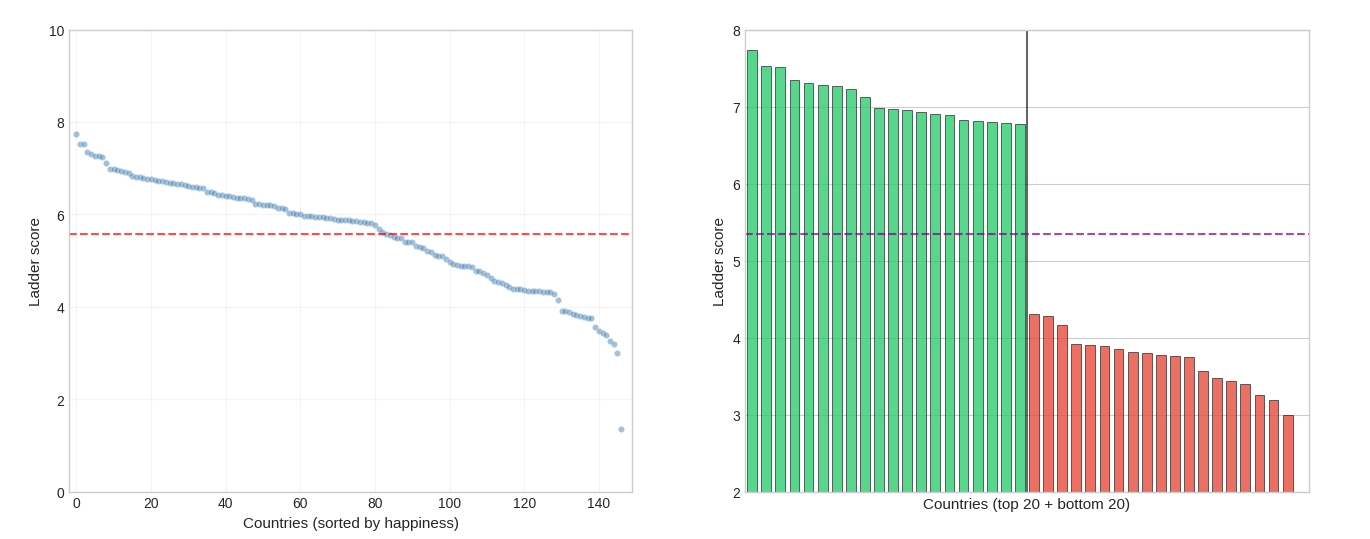

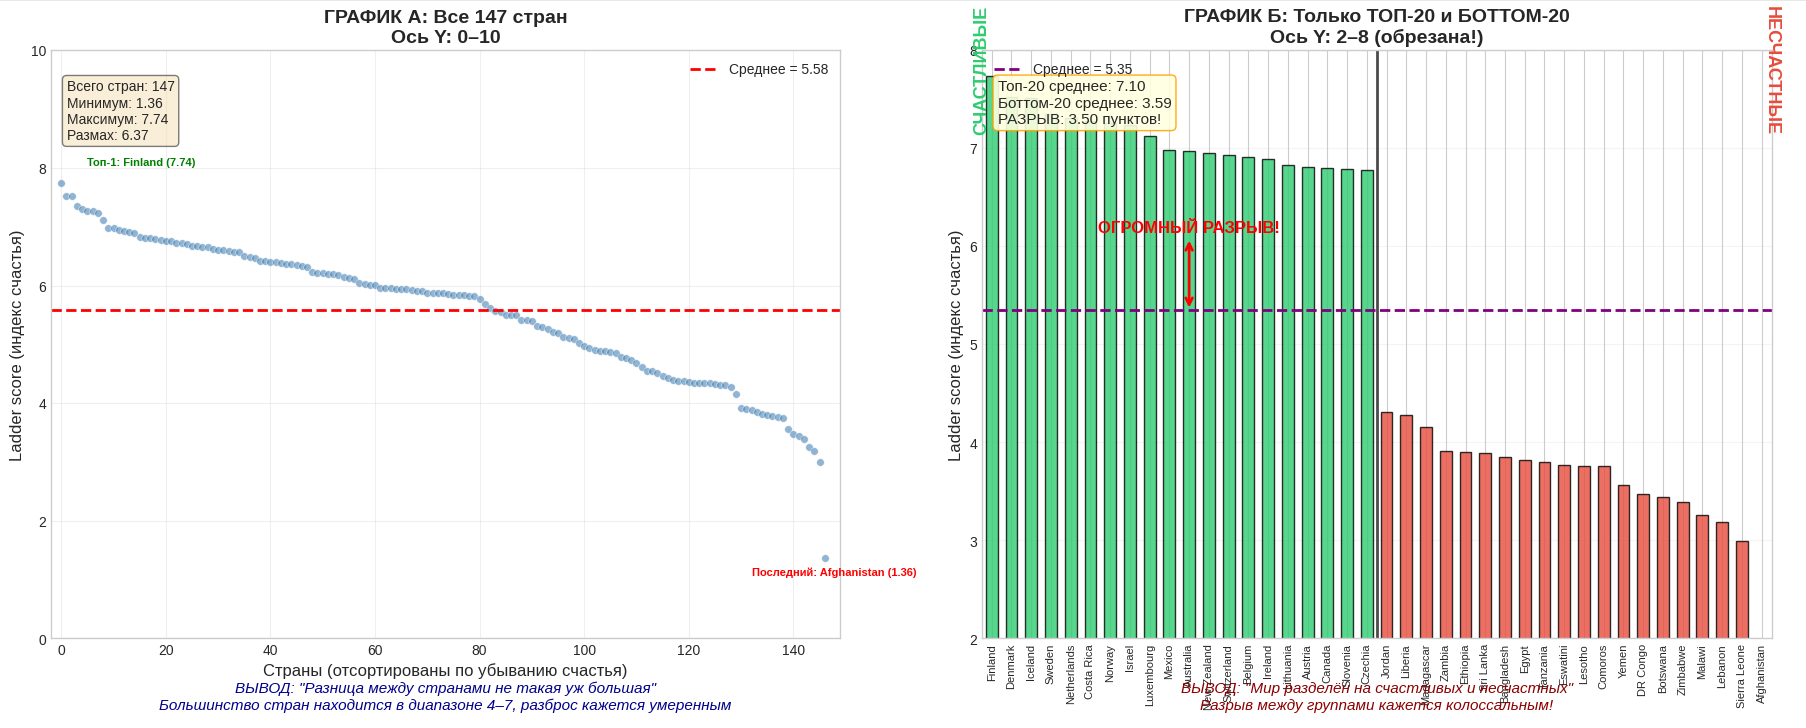

**График А** (гипотетический): Ось Y от 0 до 10, показаны все 147 стран.
Выглядит как плотное облако точек. Вывод: "Разница между странами не такая уж большая".

**График Б** (гипотетический): Ось Y от 2 до 8, показаны только ТОП-20 и БОТТОМ-20.
Выглядит как огромный разрыв. Вывод: "Мир разделён на счастливых и несчастных".




---


Одни и те же данные - два разных впечатления - два разных решения.

**Вывод:** Выбор типа графика, масштаба, выборки и подписей —
это не техническая, а **этическая и стратегическая** задача.

## Цели и артефакт

#### Цели занятия
К концу занятия мы сможем:
1.  **Формулировать** исследовательские вопросы к реальным данным (WHR).
2.  **Выбирать** правильный тип графика для этого вопроса.
3.  **Строить** графики в Python (Pandas + Matplotlib + Seaborn).
4.  **Анализировать** график: видеть паттерны и ограничения.
5.  **Критиковать** чужие графики (и свои собственные) на предмет искажений.

### КОНЕЧНЫЙ АРТЕФАКТ

К концу занятия мы создадим **Графический мини-отчёт** по данным WHR_2025.

**Отчёт должен содержать:**
1.  **3 графика** разных типов (из 4 базовых).
2.  Под каждым графиком:
    - **Наблюдение** (что мы видим, 1-2 предложения).
    - **Ограничение** (чего мы НЕ видим, что нельзя утверждать).
3.  **Итоговый вывод** (3-5 предложений) — что делает страны счастливыми?


## Золотое правило аналитика

> **«Прежде чем открыть Excel или написать plt.plot(), задай вопрос».**

График — это ответ на вопрос. Без вопроса график бессмыслен.

---

####  4 базовых типа вопросов к данным

| № | Тип вопроса | Формулировка | Пример по WHR |
|---|-------------|--------------|---------------|
| 1 | **Сравнение** | Как объекты соотносятся друг с другом? | Какая страна самая счастливая? |
| 2 | **Состав** | Из каких частей состоит целое? | Какой вклад вносит ВВП в счастье? |
| 3 | **Распределение** | Как разбросаны значения? | Сколько стран имеют индекс > 6? |
| 4 | **Связь** | Как изменение X влияет на Y? | Зависит ли счастье от уровня коррупции? |


#### Упражнение для всей группы (интерактив)

Я показываю вам данные WHR. Ваша задача — **задать вопрос** к этим категориям.

**Данные:** 147 стран, 8 факторов (ВВП, соцподдержка, здоровье, свобода, щедрость, коррупция).

**Пример вариантов вопросов (запишите в чат или скажите вслух):**
- *(Сравнение)*: Какая страна самая несчастная?
- *(Состав)*: Что важнее для счастья — ВВП или свобода?
- *(Распределение)*: Как распределены страны по уровню счастья?
- *(Связь)*: Влияет ли щедрость на счастье?

**Вывод:** Один и тот же набор данных может отвечать на разные вопросы.
Ваша задача — выбрать **самые важные** вопросы для вашего исследования.


### 4 БАЗОВЫХ ТИПА ГРАФИКОВ

Каждому вопросу — свой график. Используйте эту таблицу как шпаргалку.

---

####  СТОЛБЧАТАЯ ДИАГРАММА (BAR CHART)

| Характеристика | Описание |
|----------------|----------|
| **Когда использовать** | Сравнение категорий (страны, регионы) |
| **Вопрос по WHR** | «Какая страна самая счастливая?», «Кто в ТОП-10?» |
| **Пример** | ТОП-10 стран по индексу счастья |
| **Важно** | **Сортировать** столбцы по убыванию, чтобы было видно лидеров |
| **Ошибка** | Не сортировать — тогда график превращается в «кашу» |

---


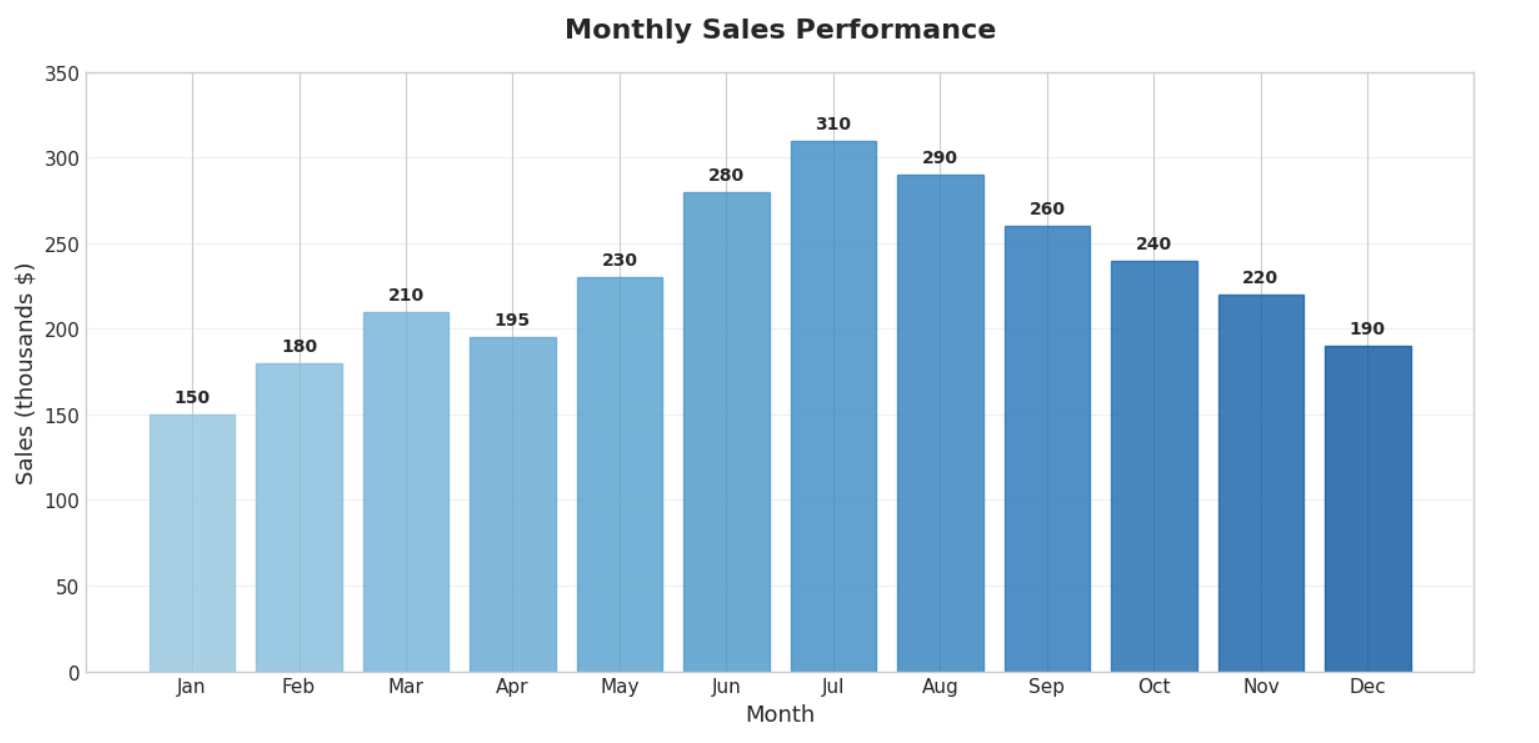


#### ГИСТОГРАММА (HISTOGRAM)

| Характеристика | Описание |
|----------------|----------|
| **Когда использовать** | Распределение непрерывных данных |
| **Вопрос по WHR** | «Как распределены страны по уровню счастья?» |
| **Пример** | Распределение Ladder Score по 147 странам |
| **Важно** | Правильно выбрать количество **bins** (столбцов) |
| **Ошибка** | Путать гистограмму со столбчатой диаграммой |

---


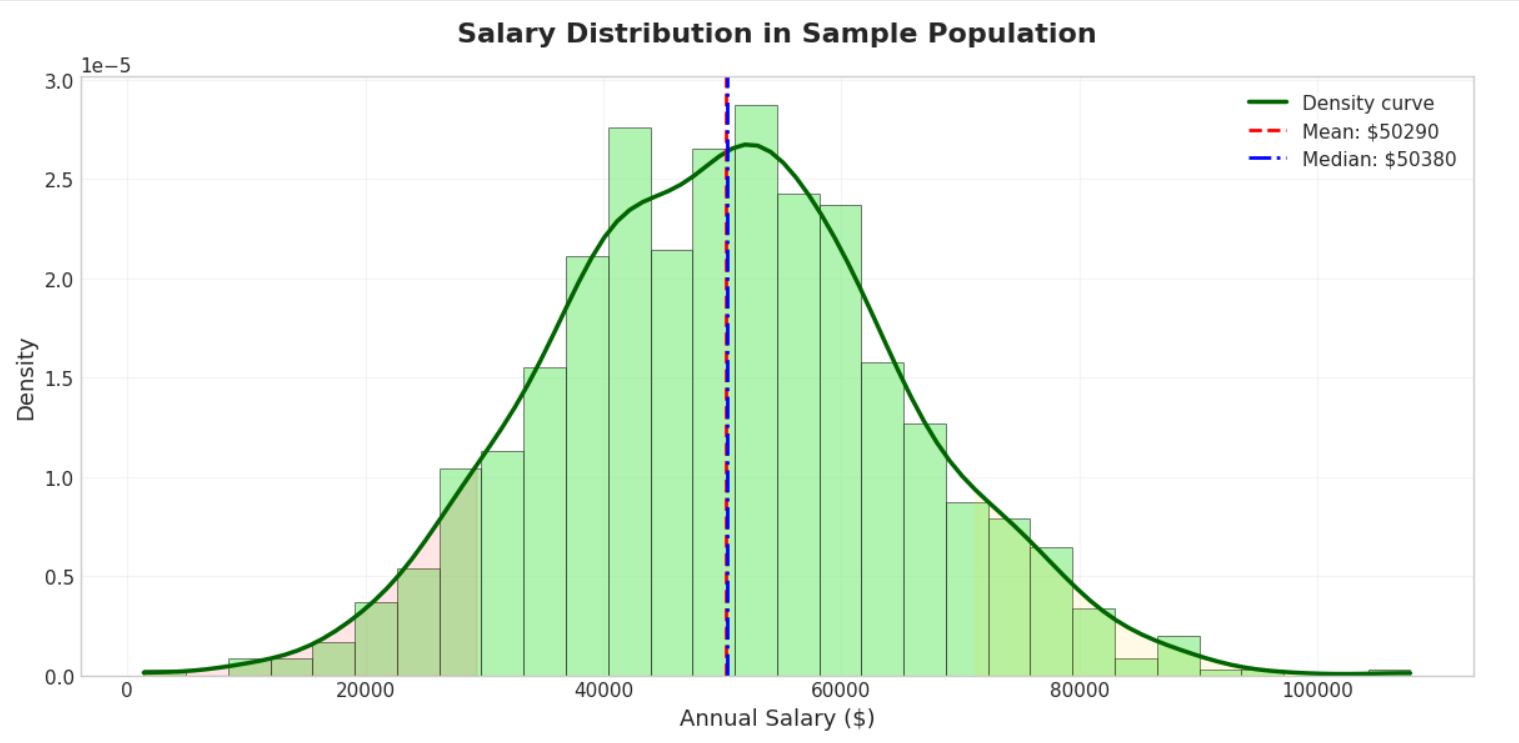


#### ТОЧЕЧНЫЙ ГРАФИК (SCATTER PLOT)

| Характеристика | Описание |
|----------------|----------|
| **Когда использовать** | Изучение связи между двумя переменными |
| **Вопрос по WHR** | «Зависит ли счастье от ВВП?», «Влияет ли коррупция?» |
| **Пример** | Ladder Score vs Log GDP per capita |
| **Важно** | Смотреть на **форму облака** точек |
| **Ошибка** | Делать вывод о причинности («А вызывает Б») |

---


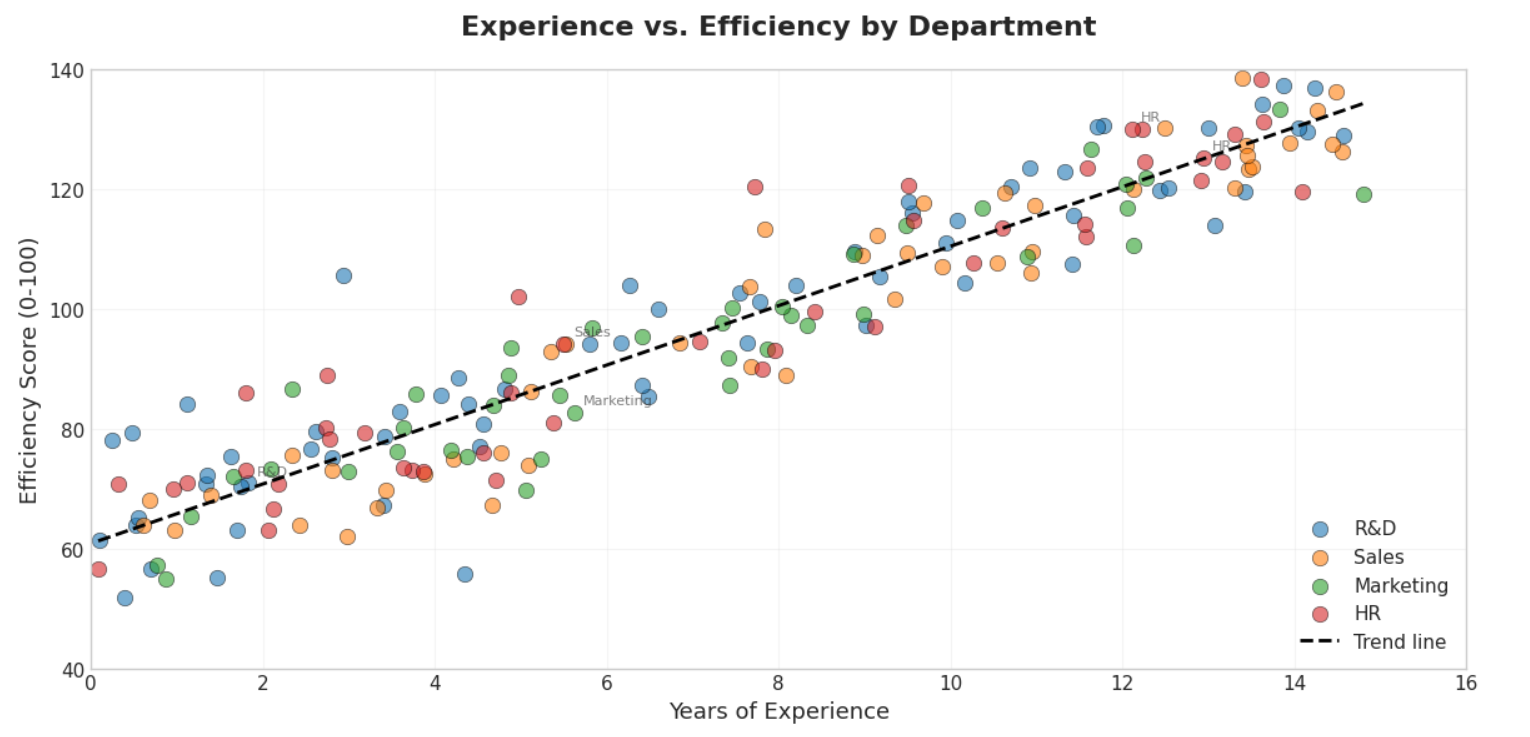

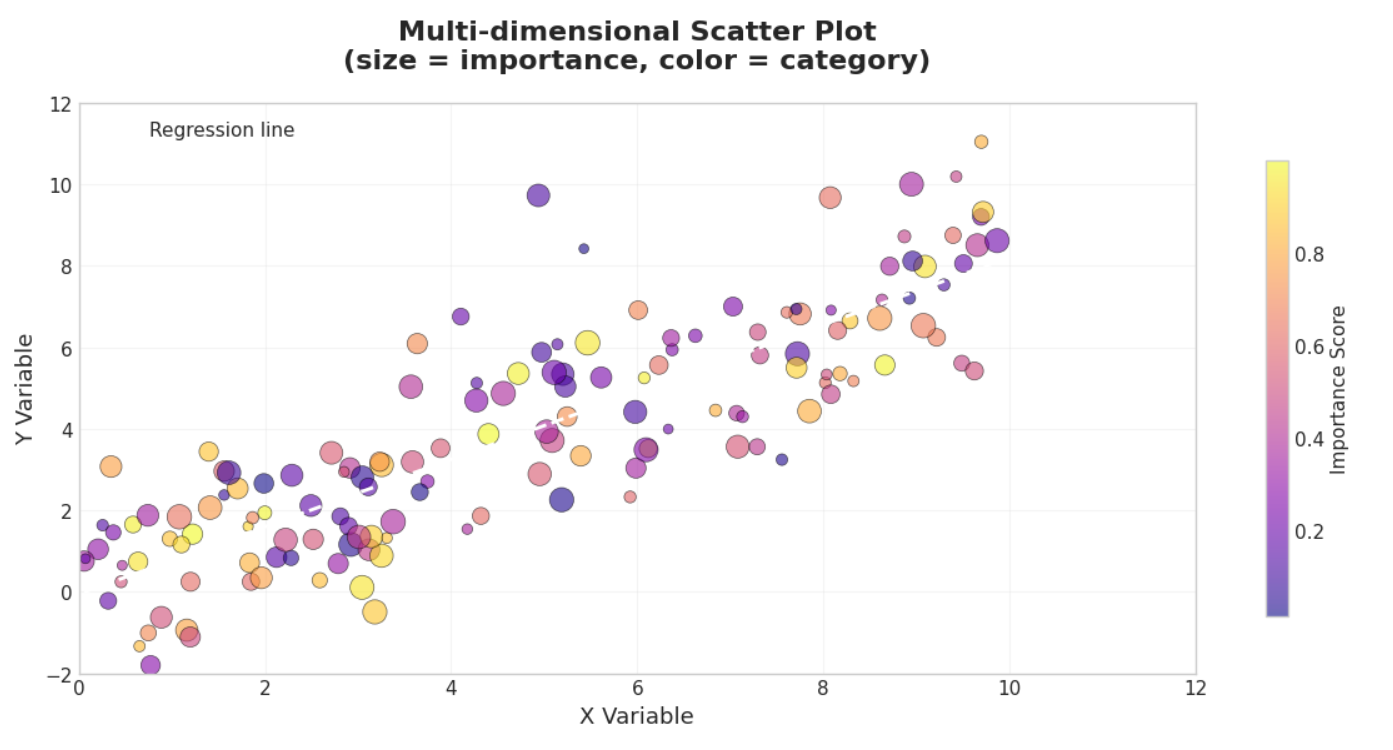


#### ТЕПЛОВАЯ КАРТА (HEATMAP) / МАТРИЦА КОРРЕЛЯЦИЙ

| Характеристика | Описание |
|----------------|----------|
| **Когда использовать** | Показ матрицы корреляций между множеством переменных |
| **Вопрос по WHR** | «Какие факторы сильнее всего влияют на счастье?» |
| **Пример** | Корреляция между всеми 6 факторами и Ladder Score |
| **Важно** | Цветовая шкала должна быть интуитивной |
| **Ошибка** | Использовать для категориальных данных |

---


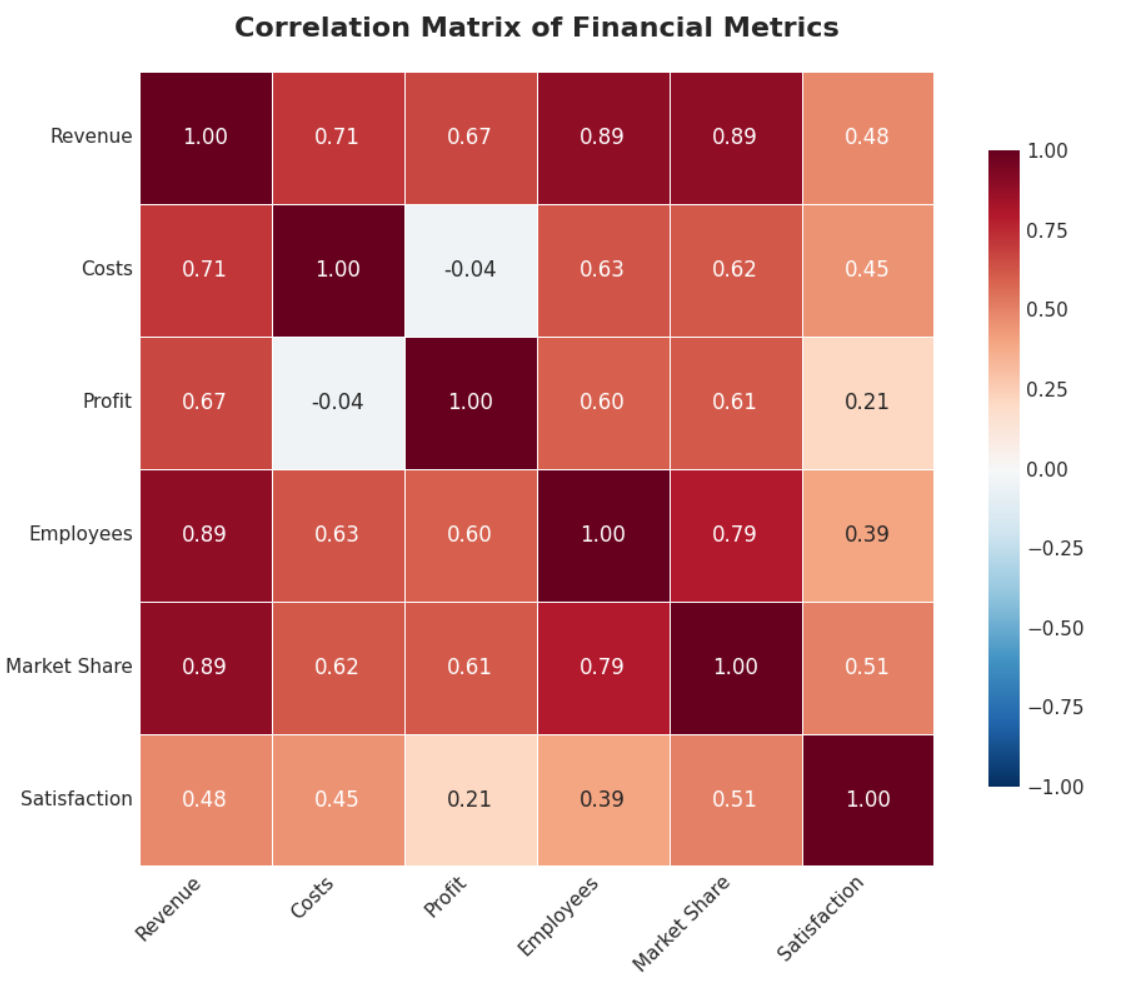


#### Сводная таблица: вопрос - график

| Ваш вопрос по WHR | Какой график выбрать |
|-------------------|----------------------|
| Какая страна самая счастливая? | Столбчатая диаграмма (ТОП-10) |
| Каково распределение счастья в мире? | Гистограмма |
| Влияет ли ВВП на счастье? | Точечный график |
| Какие факторы важнее всего для счастья? | Тепловая карта корреляций |

### Анатомия ошибок

График — это мощный инструмент, но он легко может обмануть. Рассмотрим ключевые и самые частые ошибки:
---

#### ОШИБКА 1: ПЛОХИЕ ПОДПИСИ

**Проблема:** Подписи осей неинформативны или отсутствуют.

**Пример:** На оси Y написано просто «Значение».

**Решение:** Всегда пишите: «Индекс счастья (Ladder Score)», «ВВП на душу населения (лог)».

---

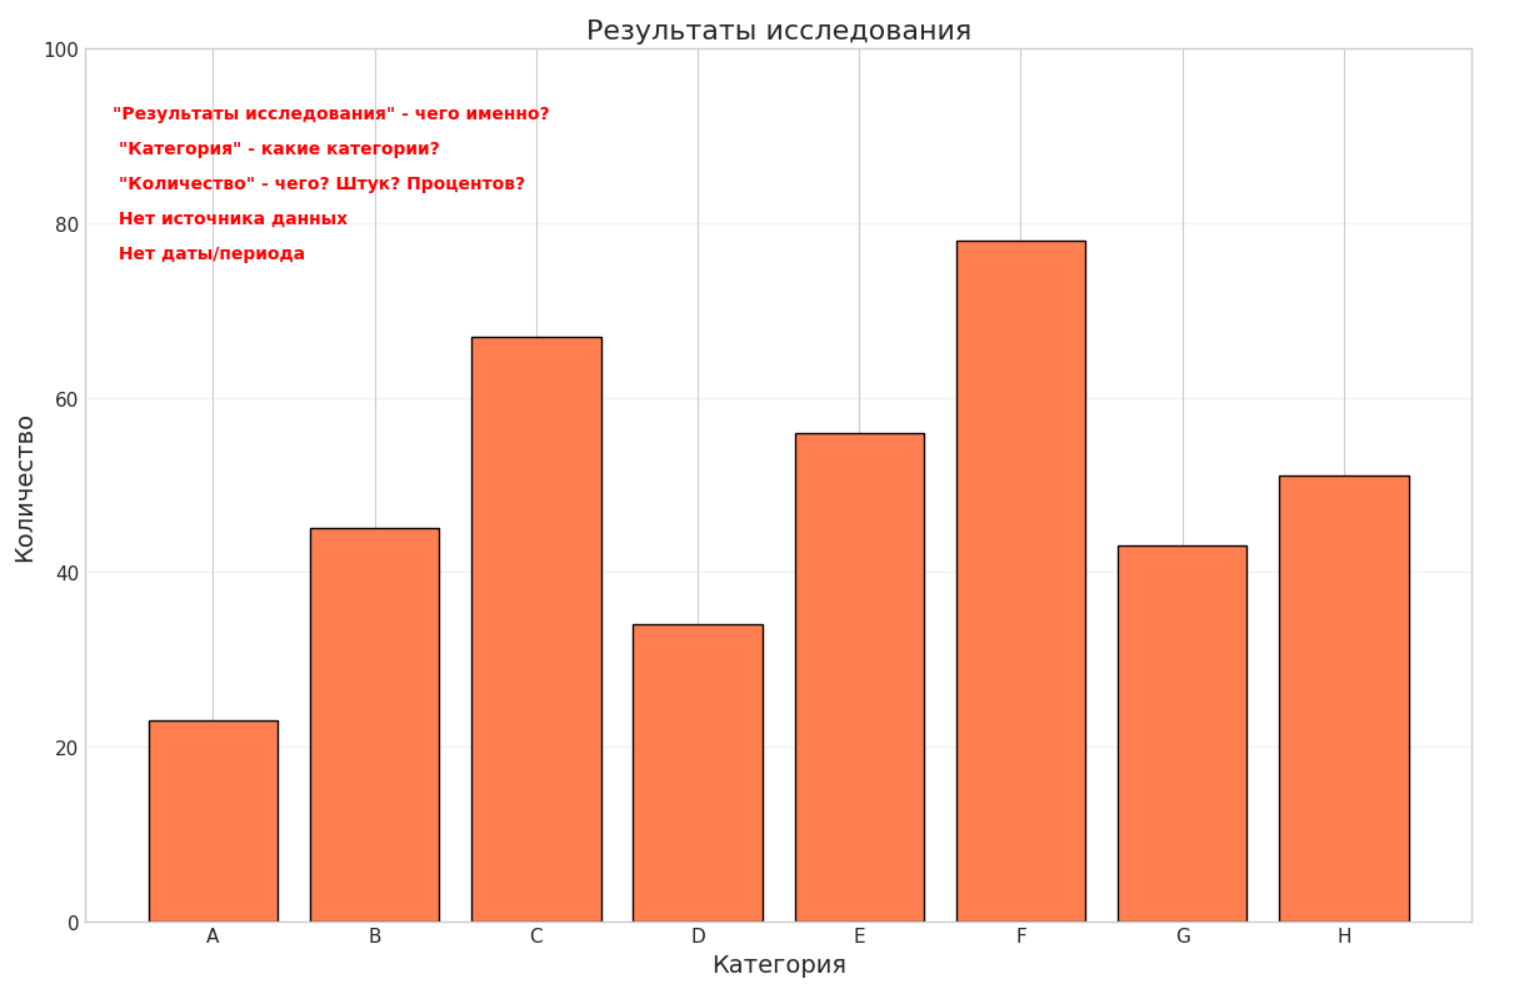

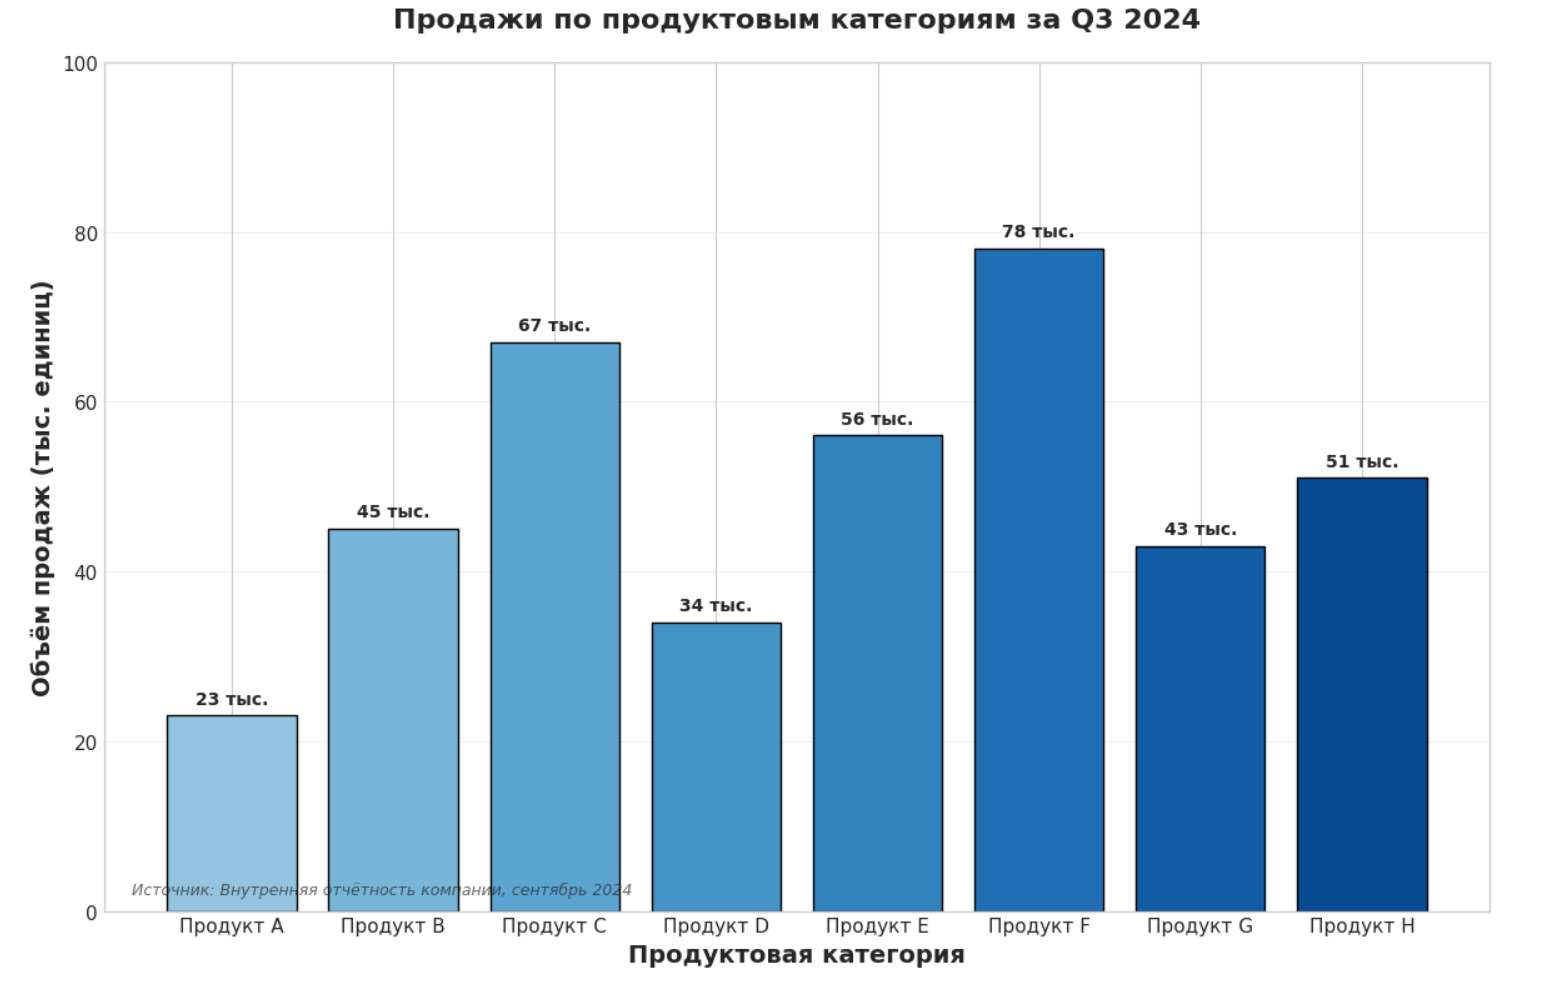



#### ОШИБКА 2: НЕПРАВИЛЬНЫЙ МАСШТАБ (САМАЯ ЧАСТАЯ)

**Проблема:** Ось Y начинается не с нуля.

**Эффект:** Разница между 7.5 и 6.5 кажется огромной.

**Решение:** Для столбчатых диаграмм ось Y **всегда** должна начинаться с 0.

---

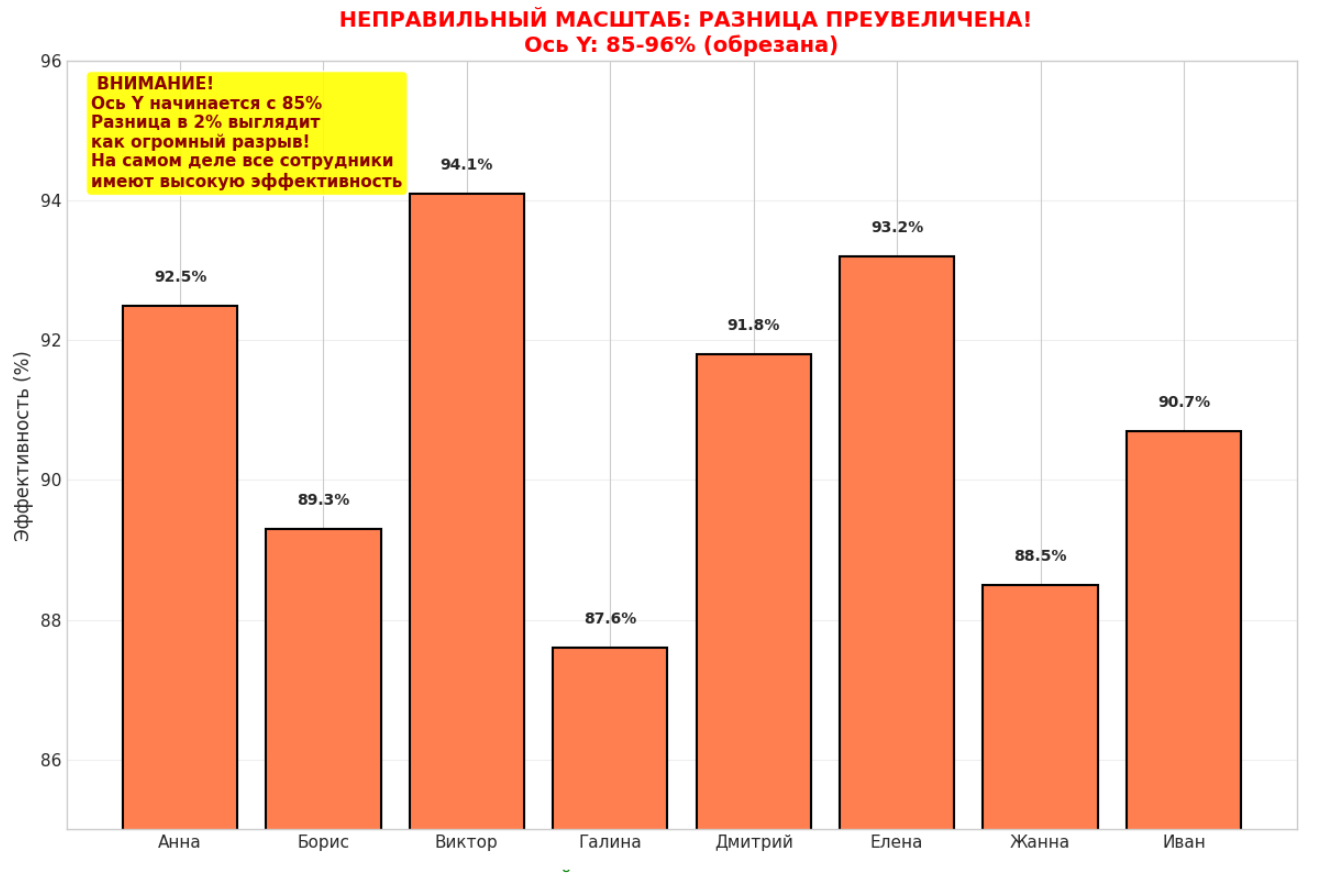

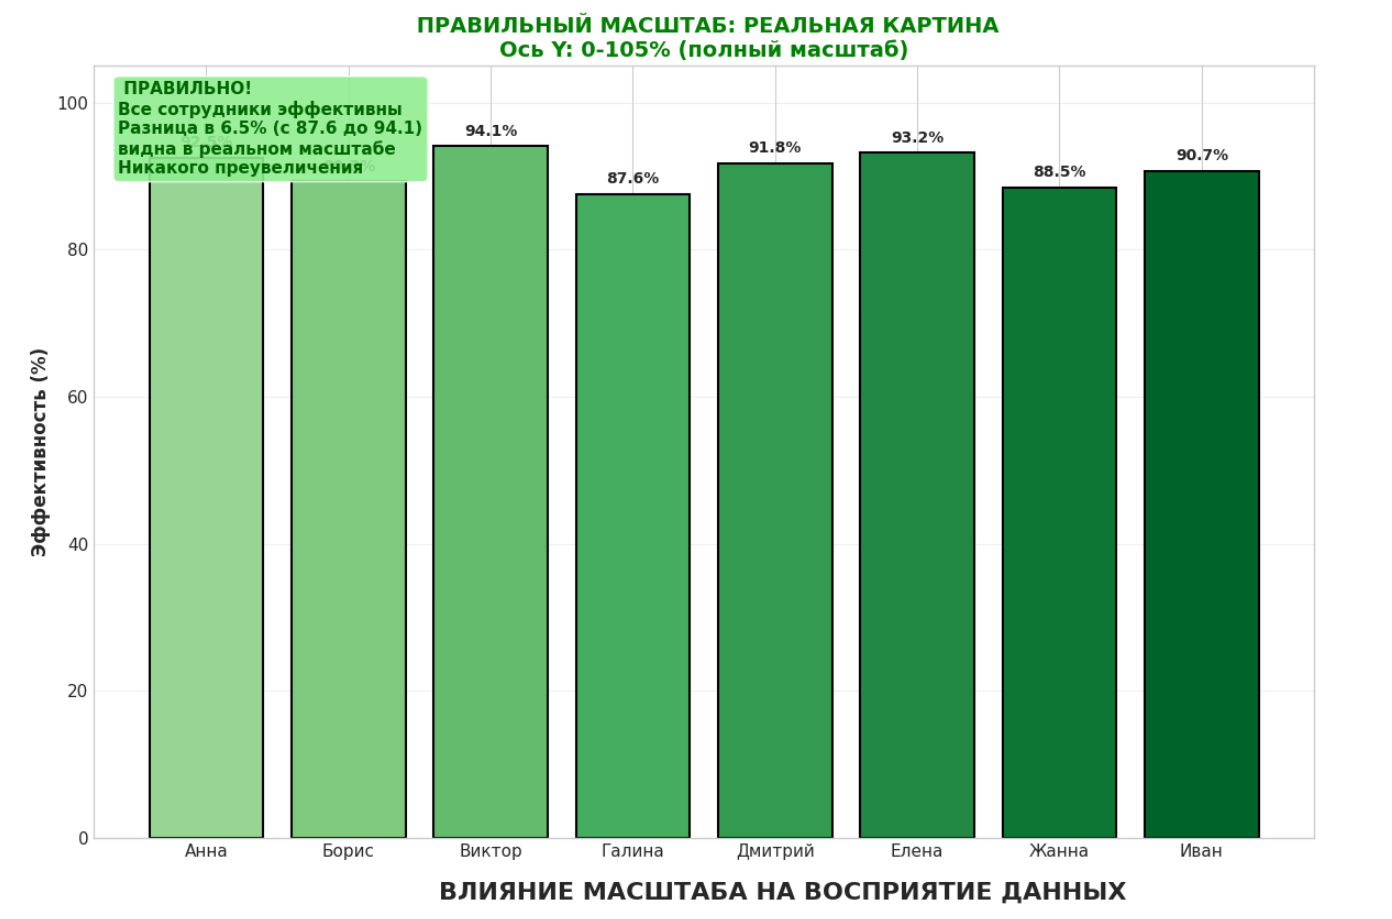



#### ОШИБКА 3: ОТСУТСТВИЕ СОРТИРОВКИ

**Проблема:** Страны расположены в алфавитном порядке.
**Эффект:** Глаз «сканирует» данные хаотично.
**Решение:** Всегда сортируйте столбцы по убыванию или возрастанию.

---


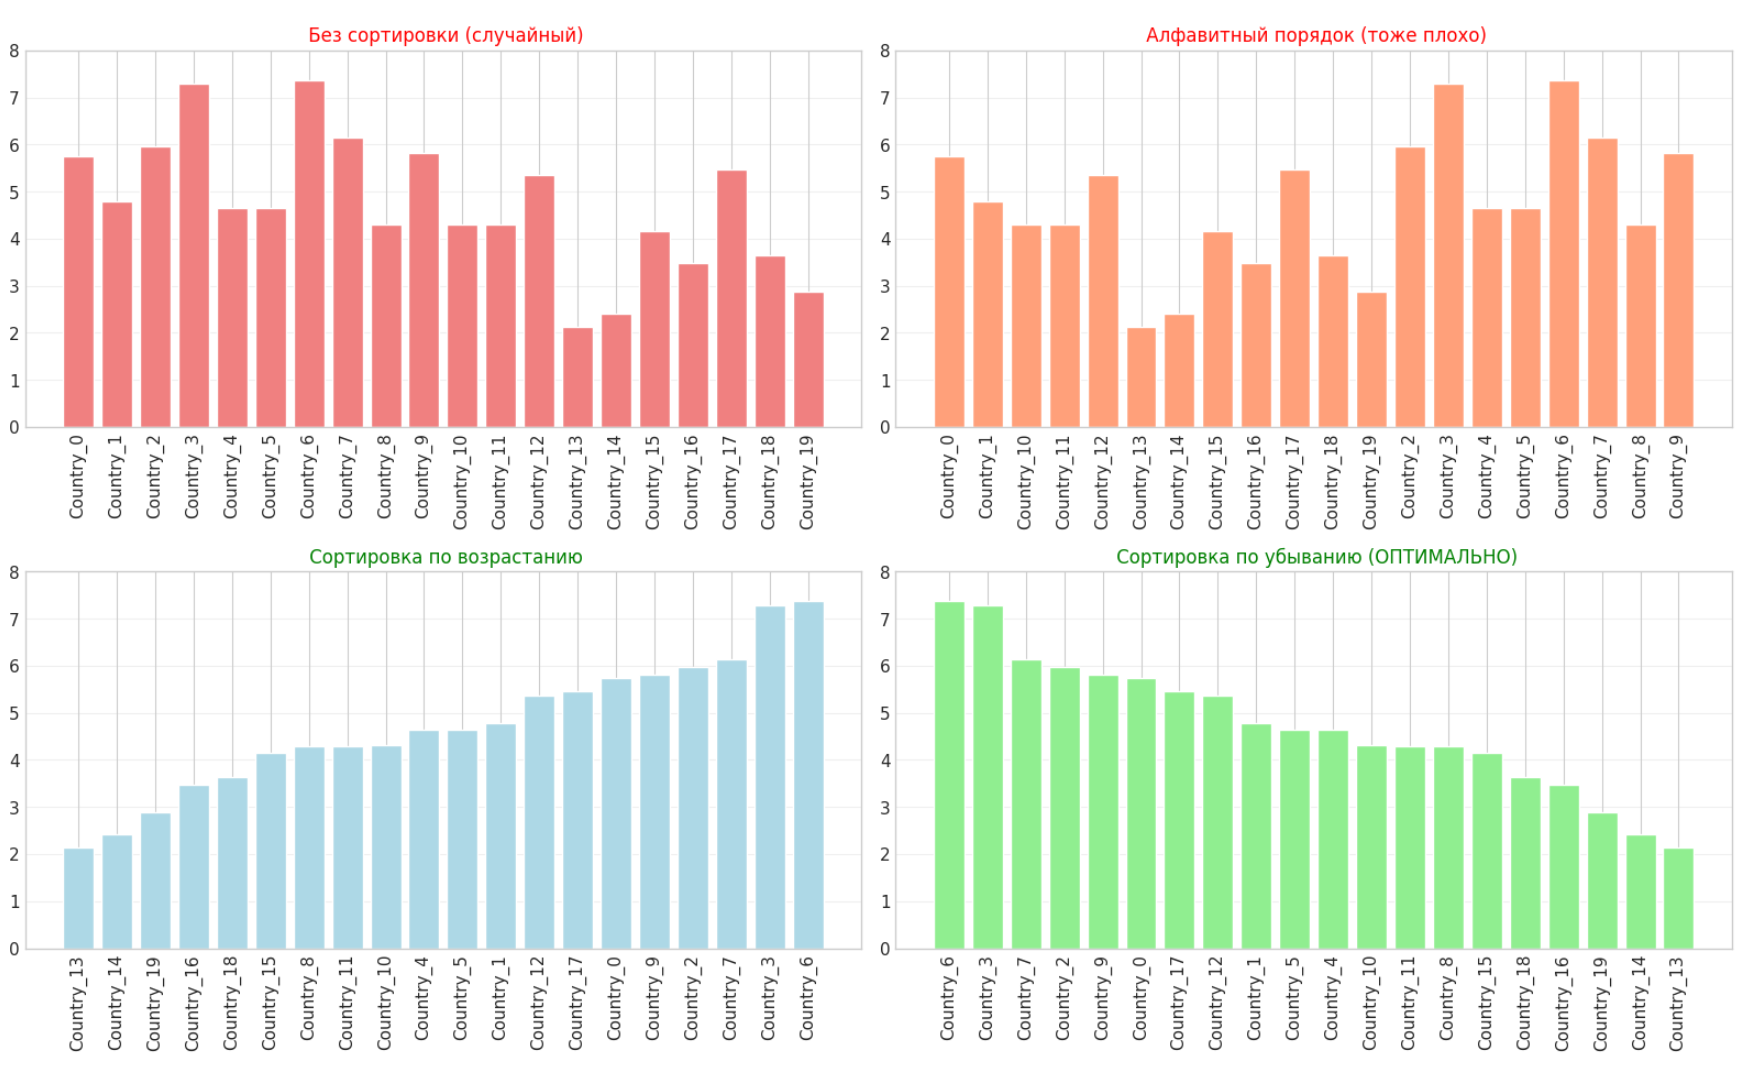


#### ОШИБКА 4: ПЕРЕИЗБЫТОК ЦВЕТА

**Проблема:** Каждый столбец или точка окрашены в свой яркий цвет.
**Эффект:** Вместо анализа данных вы смотрите на радугу.
**Решение:** Используйте 1-2 цвета для основного графика.

---


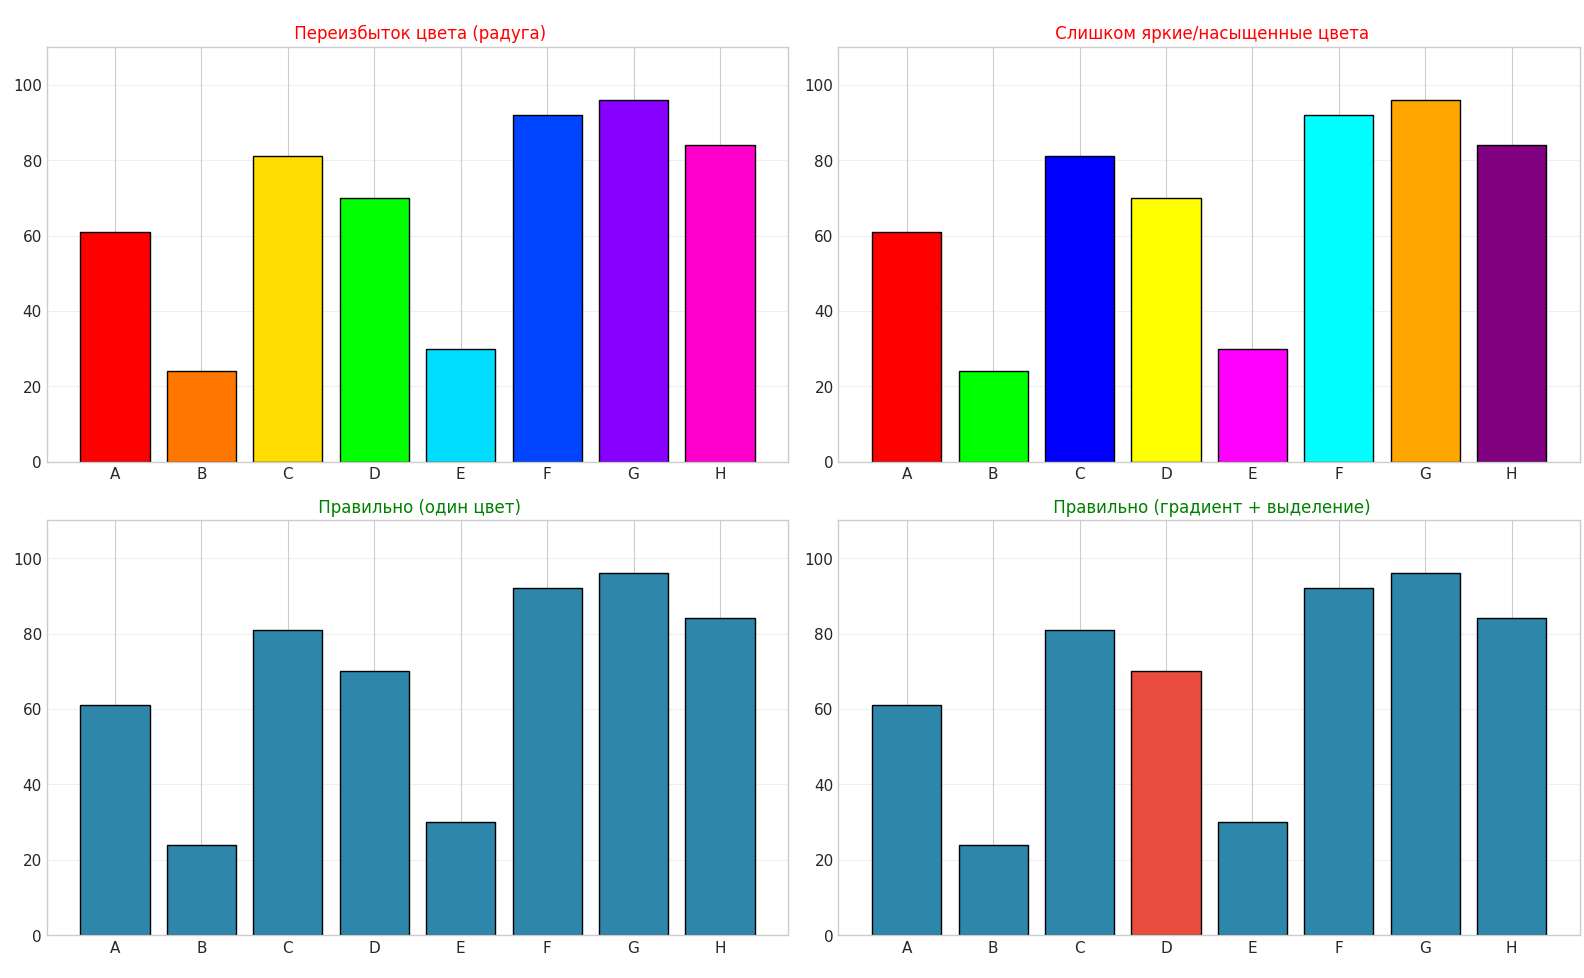


#### ОШИБКА 5: КОРРЕЛЯЦИЯ ≠ ПРИЧИННОСТЬ

**Проблема:** «На графике видно, что X растёт вместе с Y - X влияет на Y».

**Правда:** Корреляция не равна причинности.

**Пример:** Счастье и ВВП коррелируют, но ВВП не гарантирует счастье (и наоборот).

**Решение:** В выводах пишите «связаны», «коррелируют», «наблюдается тенденция».

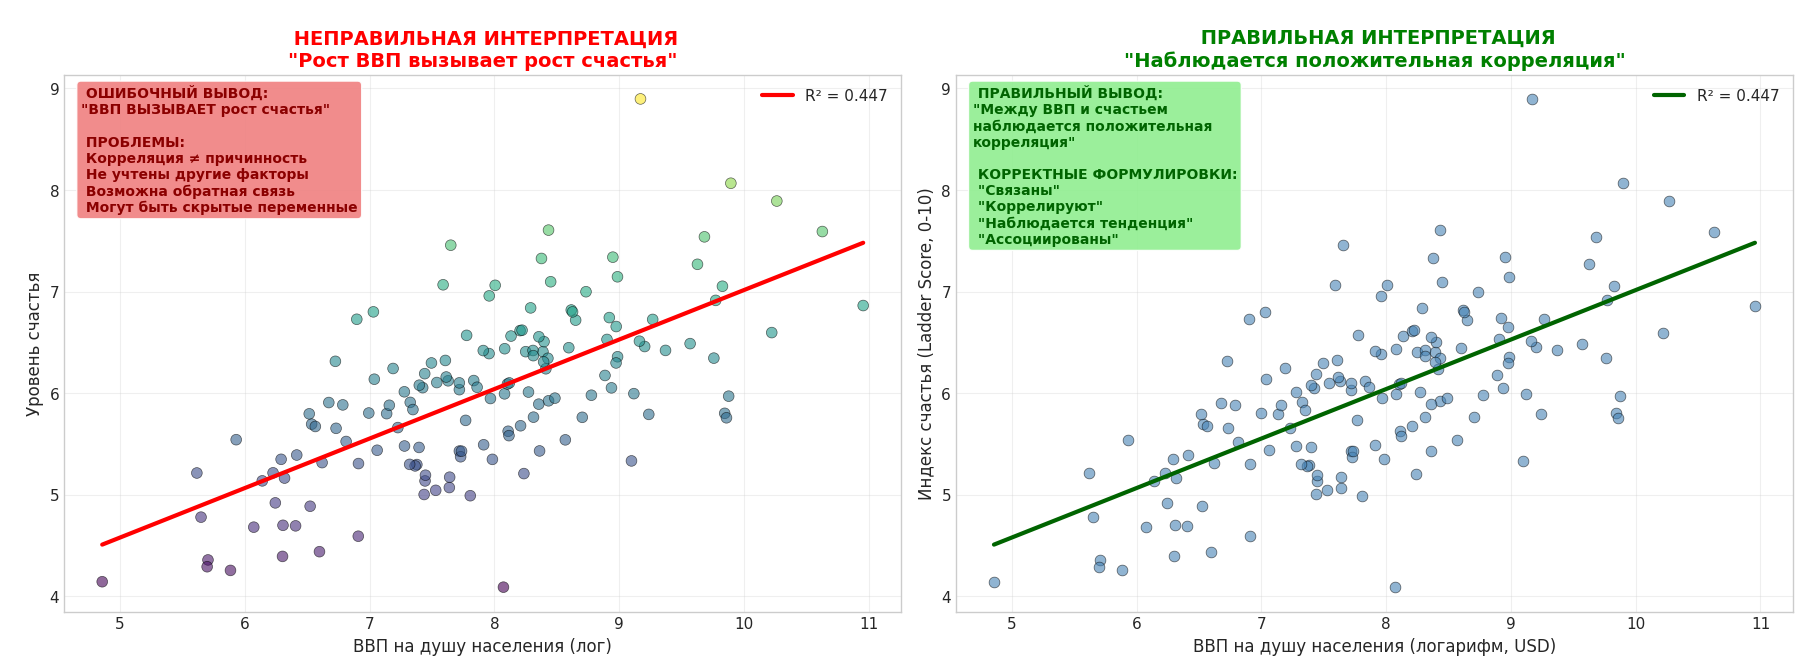

# Построение графиков из сценария

используя файлы например main.py
В таком случае необходимо использовать plt.show() которая откроет график в отдельном окне и блокирует выполнение вашей программы, пока график не будет закрыт. Т.к. здесь мы используем colab, у нас не будет выполнено этого прерывания

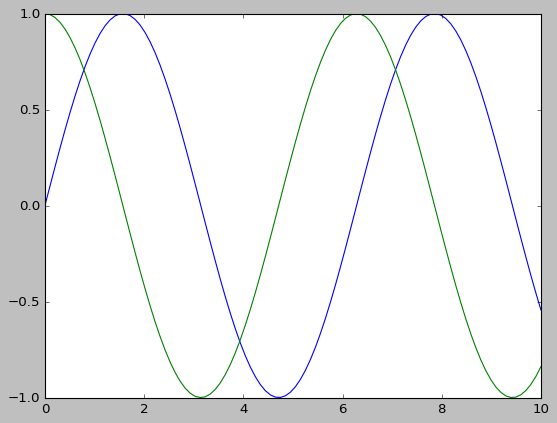

In [ ]:
# main.py
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)

plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))

plt.show() # Команда про которую идет речь, всё что выше и связано с plt, будет рассмотрено позже
# ВАЖНО использовать команду show() в таком случае можно только ОДИН раз и чаще всего выполнение в конце кода

Интерактивный режим в оболочке IPython:


*   команду можно не использовать
*   после каждой команды вызывается `show()` автоматически
*   Некоторые изменения стиля не будут применяться автоматически, необходимо вручную прописывать `plt.show()`, `plt.draw()`

Пример:

```
In [1]: %matplotlib
Using matplotlib backend: TkAgg
In [2]: import matplotlib.pyplot as plt
```



Браузерные интерактивные оболочки IPython (colab, Jupyter и другие):
* есть два режима: %matplotlib notebook (интерактивные графики), второй - %matplotlib inline (статичные графики) - по умолчанию встроенные png изображения
* Отображение графиков не прерывает код ниже
* Использовать show() не обязательно

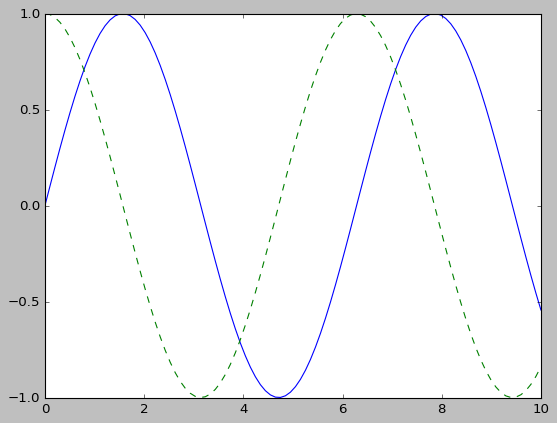

In [ ]:
import numpy as np
x = np.linspace(0, 10, 100)

fig = plt.figure()
plt.plot(x, np.sin(x), '-')
plt.plot(x, np.cos(x), '--');


# Сохранение графиков
Можно сохранять предыдущий построенный график с помощью команды savefig()

In [ ]:
fig.savefig('my_figure.png')

Если использовать colab, то график созраниться во временное рабочее пространство. **После завершения сеанса он УДАЛИТСЯ**

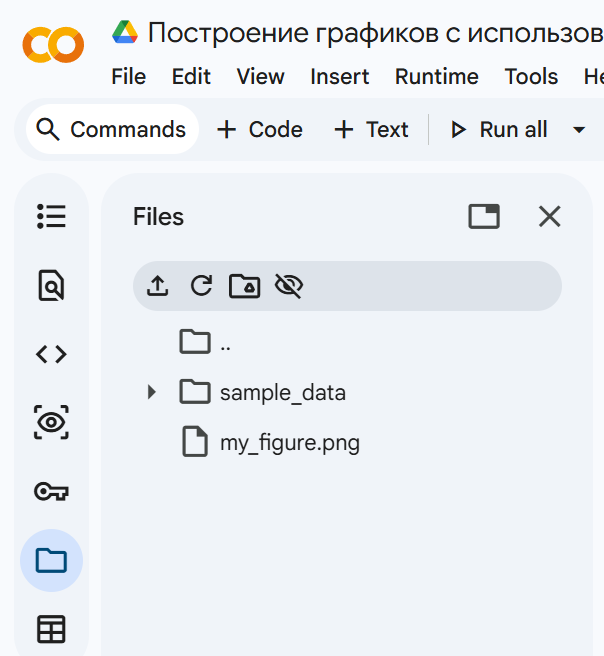

Поддерживаемые форматы созранения можно проверить командой

In [ ]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

# Объектно-ориентированный интерфейс

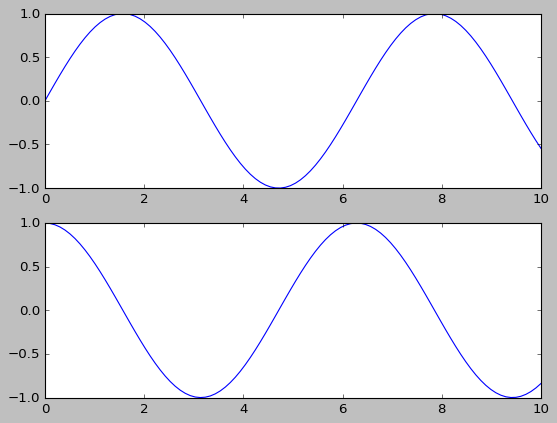

In [ ]:
# Сначала создаем сетку графиков
# ax будет массивом из двух объектов Axes (оси)
fig, ax = plt.subplots(2)

# Вызываем метод plot() соответствующего объекта
ax[0].plot(x, np.sin(x))
ax[1].plot(x, np.cos(x));

# Кадый можно менять отдельно, а не только последний


# Типы графиков

Простые линейные графики

y = f(x)

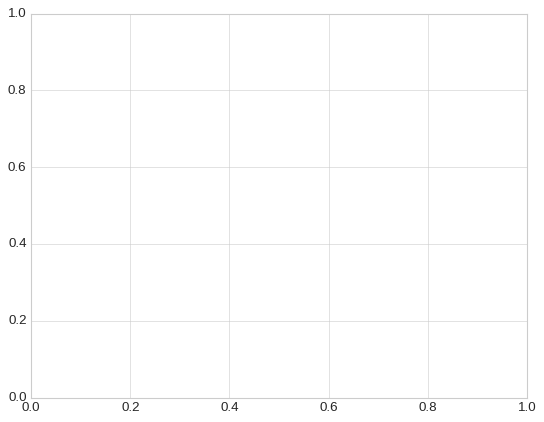

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

#Создание области рисунка и координат
fig = plt.figure()
ax = plt.axes()

График синусоиды

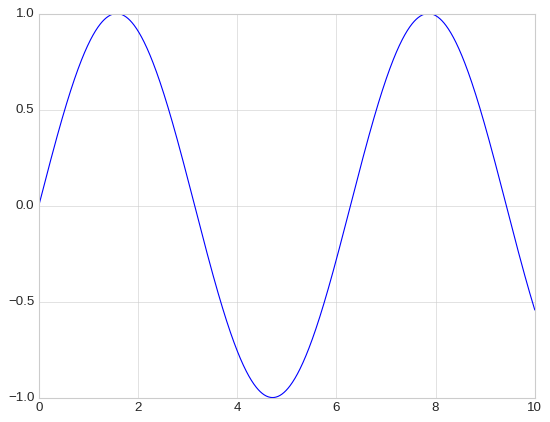

In [ ]:
fig = plt.figure()
ax = plt.axes()
x = np.linspace(0, 10, 1000)
ax.plot(x, np.sin(x))

Если нужно создать простой рисунок с несколькими графиками, то можно вызвать ```plot``` несколько раз

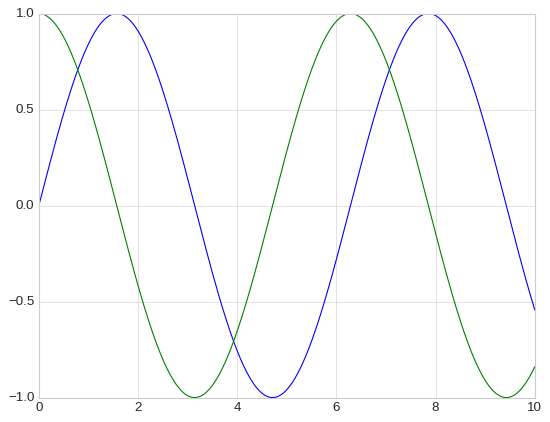

In [ ]:
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))

# Настройка графика: цвета и стили линий

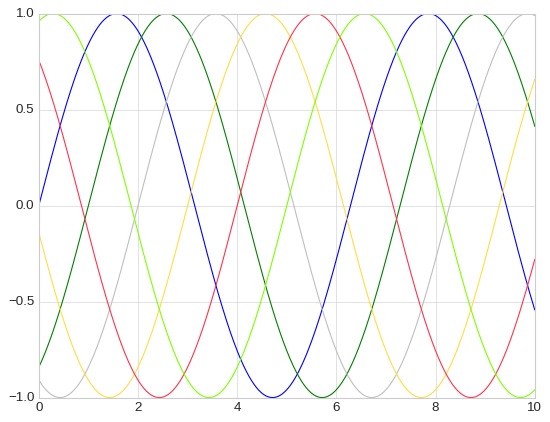

In [ ]:
# color - настройка цвета линий

plt.plot(x, np.sin(x - 0), color='blue') # Задаем цвет по названию
plt.plot(x, np.sin(x - 1), color='g') # Краткий код цвета (rgbcmyk)
plt.plot(x, np.sin(x - 2), color='0.75') # Шкала оттенков серого цвета,
                                        # значения в диапазоне от 0 до 1

plt.plot(x, np.sin(x - 3), color='#FFDD44') # 16-ричный код
                                            # (RRGGBB от 00 до FF)

plt.plot(x, np.sin(x - 4), color=(1.0,0.2,0.3)) # Кортеж RGB, значения 0 и 1
plt.plot(x, np.sin(x - 5), color='chartreuse'); # Поддерживаются все названия
                                                # цветов HTML

Стиль линий можно настраивать и с помощью ключевого слова linestyle

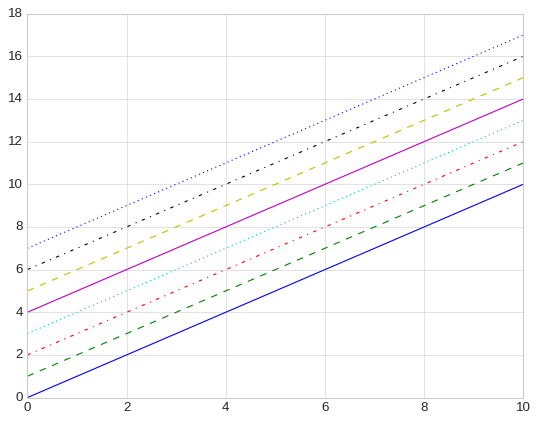

In [ ]:
plt.plot(x, x + 0, linestyle='solid')
plt.plot(x, x + 1, linestyle='dashed')
plt.plot(x, x + 2, linestyle='dashdot')
plt.plot(x, x + 3, linestyle='dotted');
# Можно использовать и следующие сокращенные коды:
plt.plot(x, x + 4, linestyle='-') # сплошная линия
plt.plot(x, x + 5, linestyle='--') # штриховая линия
plt.plot(x, x + 6, linestyle='-.') # штрихпунктирная линия
plt.plot(x, x + 7, linestyle=':'); # пунктирная линия

Настройка графика: пределы осей координат

методы plt.xlim() и plt.ylim() - ограничение по x и по y соответственно

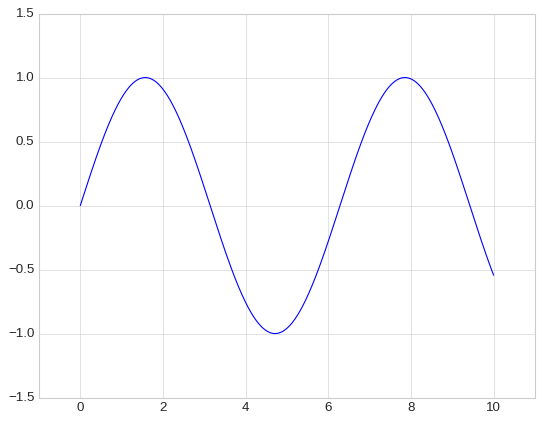

In [ ]:
plt.plot(x, np.sin(x))
plt.xlim(-1, 11)
plt.ylim(-1.5, 1.5);

Так же можно сократить запись до выражения axis([x1, x2, y1, y2])

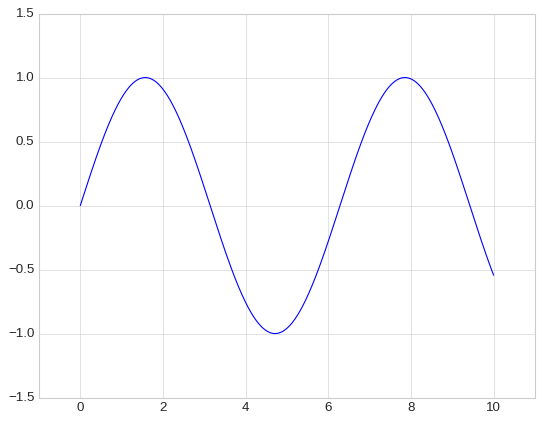

In [ ]:
plt.plot(x, np.sin(x))
plt.axis([-1, 11, -1.5, 1.5]);

axis('tight') - подгоняет границы графика

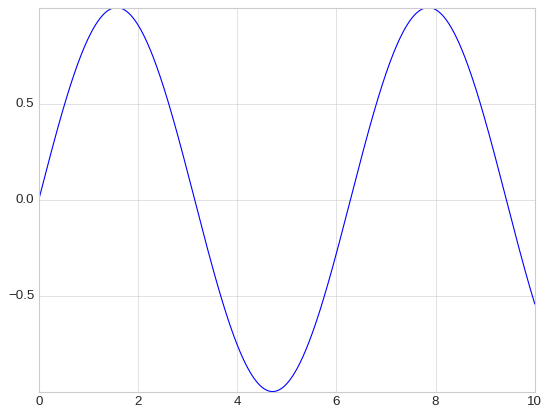

In [ ]:
plt.plot(x, np.sin(x))
plt.axis('tight');

# Метки на графиках
Названия и метки осей — простейшие из подобных меток

Text(0, 0.5, 'sin(x)')

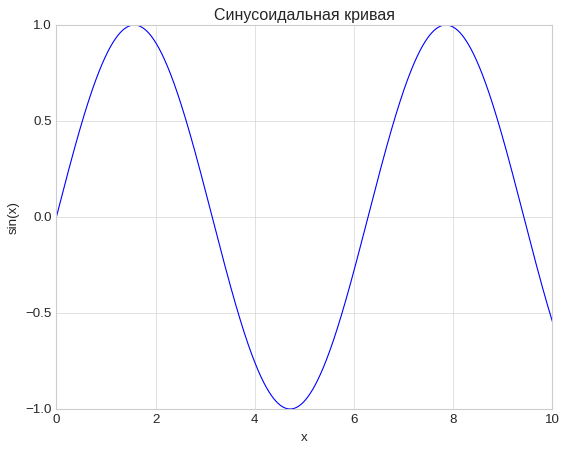

In [ ]:
plt.plot(x, np.sin(x))
plt.title("Синусоидальная кривая") # Название графика
plt.xlabel("x") # название для х
plt.ylabel("sin(x)") # название для у

Для добавления легенды графика есть втроенный метод .legend()

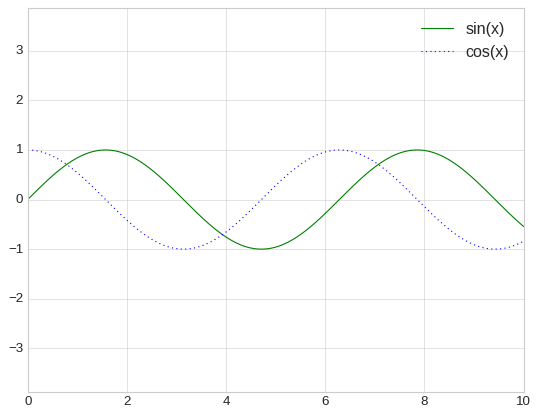

In [ ]:
plt.plot(x, np.sin(x), '-g', label='sin(x)')
plt.plot(x, np.cos(x), ':b', label='cos(x)')
plt.axis('equal')
plt.legend()

Нужно помнить некоторые отличия построения графиков через plt и ax. Хотя большинство команд совпадает, некоторые из них могут отличаться:

```
• plt.xlabel() → ax.set_xlabel();
• plt.ylabel() → ax.set_ylabel();
• plt.xlim() → ax.set_xlim();
• plt.ylim() → ax.set_ylim();
• plt.title() → ax.set_title().
```




# Простые диаграммы рассеяния
Диаграммы рассеивания похожи на линейные графики за тем исключением, что их можно строить несколькими способами и соединения в этом случае состоит из точек, кругов, фигур на графике.

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import numpy as np

Первый способ - построить через функцию plot

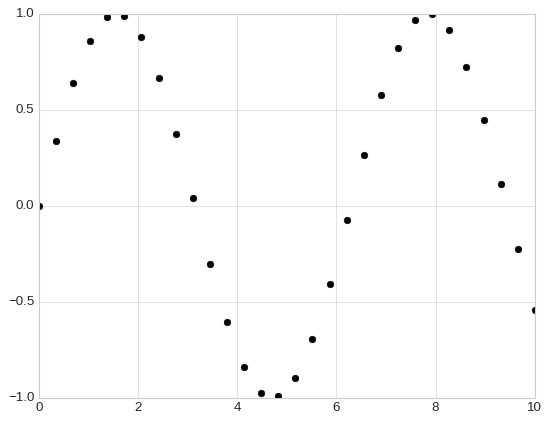

In [ ]:
x = np.linspace(0, 10, 30)
y = np.sin(x)

plt.plot(x, y, 'o', color='black') # третий аргумент тип символа, можно использовать такие как: о, -, -- и другие

Второй способ - через функцию scatter

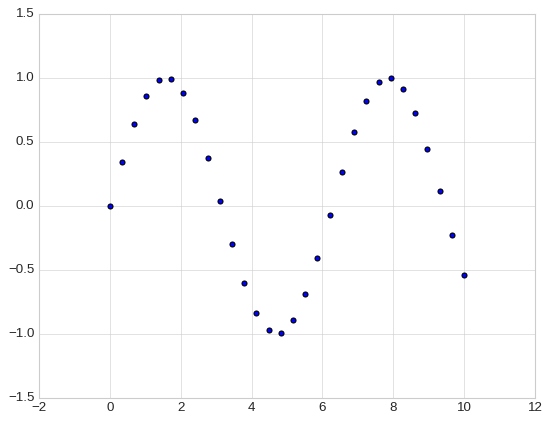

In [ ]:
plt.scatter(x, y, marker='o')

Отличие scatter от plot в том, что в scatter можно задавать параметры для каждой точки графика отдельно, а не всем сразу, то есть более гибкая настройка, НО когда вычислений очень много, то более произодительным оказывается plot.
Учитывайте это при построении графиков на реальных огромных количествах данных

In [ ]:
rng = np.random.RandomState(0)
x = rng.randn(100)
y = rng.randn(100)
colors = rng.rand(100)
sizes = 1000 * rng.rand(100)

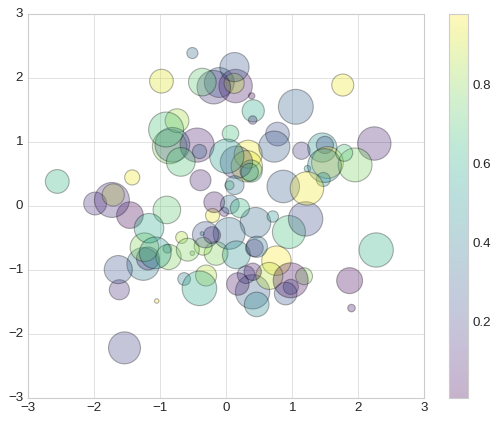

In [ ]:
plt.scatter(x, y, c=colors, s=sizes, alpha=0.3, # alpha - прозрачность
            cmap='viridis') # cmap - цветовая шкала
plt.colorbar(); # Отображаем цветовую шкал

Теперь давайте возьмем более реальный пример, чтобы цвета и размеры от чего-то зависили, а не были оторваны.

In [ ]:
# Раздел загрузки популярных данных
"""
Краткое пояснение:
Это набор о данных цветах ириса. В нем три вида ириса, у каждого из которых
отличаются размеры чашелистика и лепестка.
Очень часто используется для теории и практики при класстеризации/классификации по ИИ
"""
from sklearn.datasets import load_iris
iris = load_iris()

Text(0, 0.5, 'sepal width (cm)')

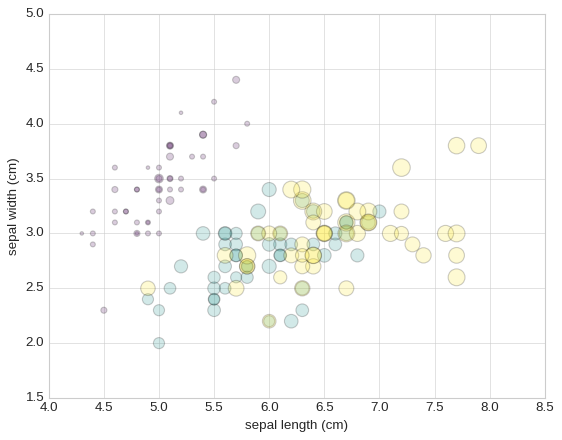

In [ ]:
features = iris.data.T
plt.scatter(features[0], features[1], alpha=0.2,
            s=100*features[3], c=iris.target, cmap='viridis')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])

# Гистограммы, разбиения по интервалам и плотность

(array([  1.,   3.,   3.,  64., 192., 262., 247., 162.,  51.,  15.]),
 array([-4.28229452, -3.56370327, -2.84511203, -2.12652078, -1.40792953,
        -0.68933828,  0.02925297,  0.74784422,  1.46643547,  2.18502672,
         2.90361797]),
 <BarContainer object of 10 artists>)

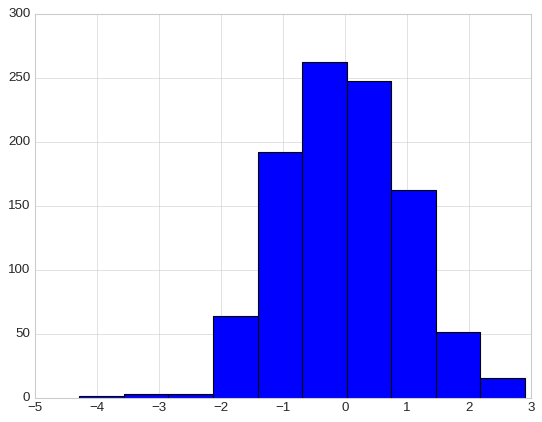

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

data = np.random.randn(1000)

plt.hist(data)


Так же по аналогии можно делать несколько гистограмм, чтобы они не сливались, можно добавлять пользовательские параметры.

 Сочетание опции
histtype='stepfilled' с заданной прозрачностью alpha очень
удобно для сравнения гистограмм нескольких распределений

(array([ 2.,  2.,  0.,  2.,  3.,  5.,  5.,  9., 15.,  9., 15., 33., 29.,
        31., 46., 41., 42., 57., 68., 62., 57., 66., 64., 54., 48., 53.,
        40., 39., 21., 15., 12., 11., 12.,  8.,  5.,  5.,  6.,  2.,  2.,
         4.]),
 array([-3.25220103, -2.94974167, -2.64728232, -2.34482297, -2.04236361,
        -1.73990426, -1.4374449 , -1.13498555, -0.83252619, -0.53006684,
        -0.22760748,  0.07485187,  0.37731123,  0.67977058,  0.98222994,
         1.28468929,  1.58714864,  1.889608  ,  2.19206735,  2.49452671,
         2.79698606,  3.09944542,  3.40190477,  3.70436413,  4.00682348,
         4.30928284,  4.61174219,  4.91420155,  5.2166609 ,  5.51912026,
         5.82157961,  6.12403896,  6.42649832,  6.72895767,  7.03141703,
         7.33387638,  7.63633574,  7.93879509,  8.24125445,  8.5437138 ,
         8.84617316]),
 [<matplotlib.patches.Polygon at 0x7b2a88506240>])

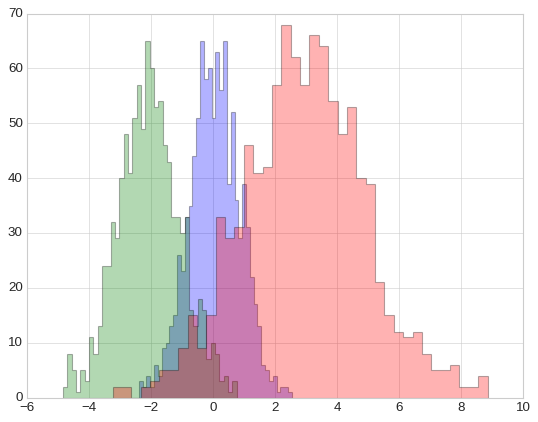

In [ ]:
x1 = np.random.normal(0, 0.8, 1000)
x2 = np.random.normal(-2, 1, 1000)
x3 = np.random.normal(3, 2, 1000)

kwargs = dict(histtype='stepfilled', alpha=0.3, bins=40)

plt.hist(x1, **kwargs)
plt.hist(x2, **kwargs)
plt.hist(x3, **kwargs)

# Выбор элементов для легенды

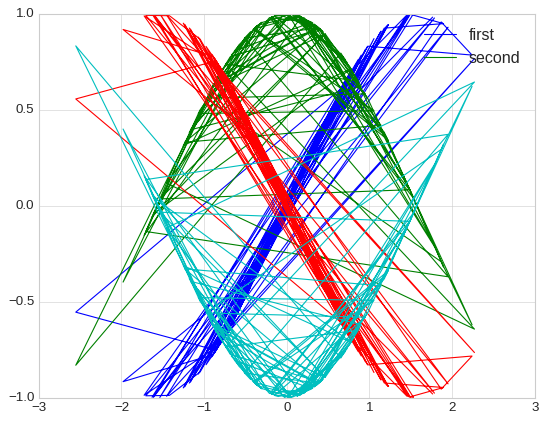

In [ ]:
y = np.sin(x[:, np.newaxis] + np.pi * np.arange(0, 2, 0.5))
lines = plt.plot(x, y)
# lines представляет собой список экземпляров класса plt.Line2D
plt.legend(lines[:2], ['first', 'second']); # Первый, второй

Обычно на практике мне удобнее использовать первый способ, указывая метки
непосредственно для элементов, которые нужно отображать в легенде

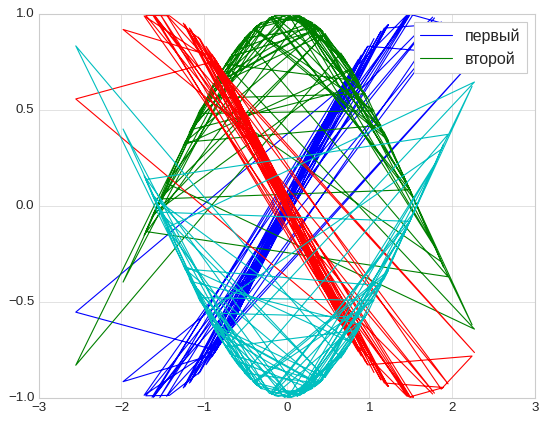

In [ ]:
plt.plot(x, y[:, 0], label='первый')
plt.plot(x, y[:, 1], label='второй')
plt.plot(x, y[:, 2:])
plt.legend(framealpha=1, frameon=True)

# Построение трехмерных графиков в библиотеке Matplotlib

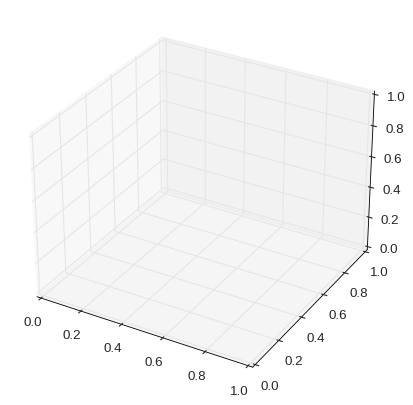

In [ ]:
from mpl_toolkits import mplot3d

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = plt.axes(projection='3d')

Трехмерные точки и линии

По аналогии с обсуждавшимися ранее более распространенными двумерными графиками их можно создать с помощью функций ax.plot3D и ax.scatter3D

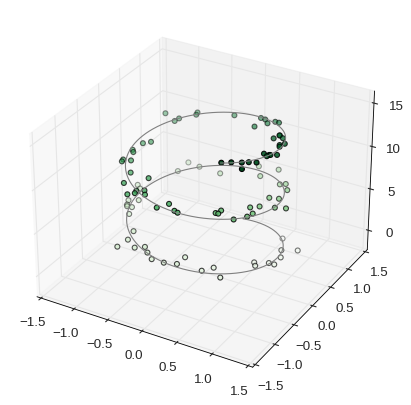

In [ ]:
ax = plt.axes(projection='3d')
# Данные для трехмерной кривой
zline = np.linspace(0, 15, 1000)
xline = np.sin(zline)

yline = np.cos(zline)
ax.plot3D(xline, yline, zline, 'gray')

# Данные для трехмерных точек
zdata = 15 * np.random.random(100)
xdata = np.sin(zdata) + 0.1 * np.random.randn(100)
ydata = np.cos(zdata) + 0.1 * np.random.randn(100)
ax.scatter3D(xdata, ydata, zdata, c=zdata, cmap='Greens')

Трехмерные контурные графики

Text(0.5, 0, 'z')

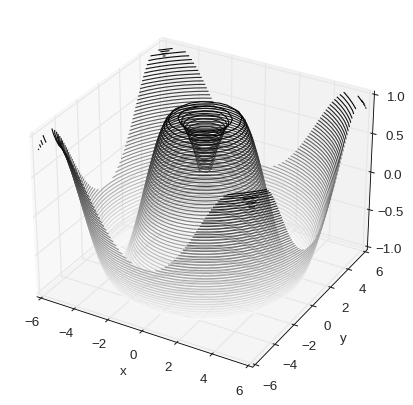

In [ ]:
def f(x, y):
 return np.sin(np.sqrt(x ** 2 + y ** 2))


x = np.linspace(-6, 6, 30)
y = np.linspace(-6, 6, 30)
X, Y = np.meshgrid(x, y) # Создание системы координат

Z = f(X, Y)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 50, cmap='binary')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')


Каркасы и поверхностные графики

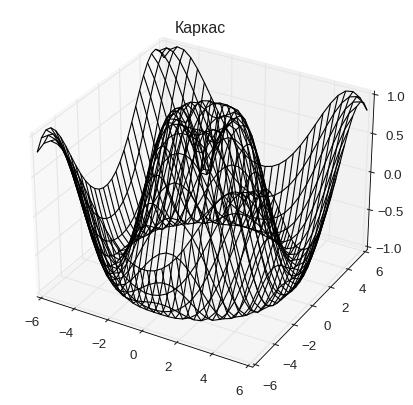

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_wireframe(X, Y, Z, color='black')
ax.set_title('Каркас'); # Каркас

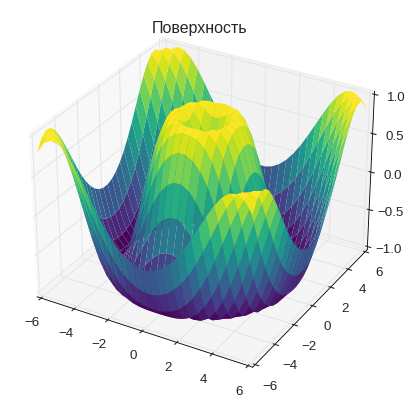

In [ ]:
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
cmap='viridis', edgecolor='none')
ax.set_title('Поверхность'); # Поверхность

# Отображение географических данных с помощью Basemap

Загрузка библиотеки

Не забудьте первый раз перезагрузить colab, python, после установки библиотеки

In [ ]:
!pip install basemap

отображаемая на рисунке сфера — не просто изображение,
это полнофункциональная система координат Matplotlib, понимающая сферические координаты и позволяющая легко дорисовывать данные на карту

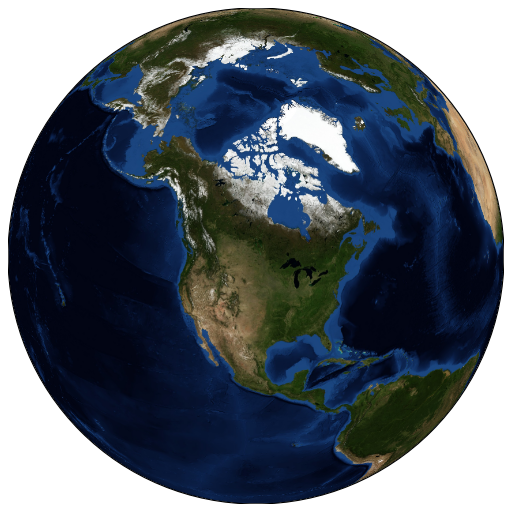

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

plt.figure(figsize=(8, 8))
m = Basemap(projection='ortho', resolution=None, lat_0=50, lon_0=-100)
m.bluemarble(scale=0.5)

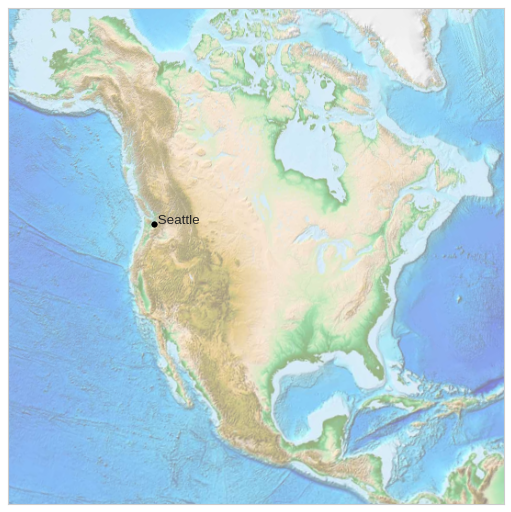

In [ ]:
fig = plt.figure(figsize=(8, 8))
m = Basemap(projection='lcc', resolution=None,
            width=8E6,
            height=8E6,lat_0=45, lon_0=-100,)

m.etopo(scale=0.5, alpha=0.5)
# Проецируем кортеж (долгота, широта) на координаты (x, y)
# для построения графика
x, y = m(-122.3, 47.6)
plt.plot(x, y, 'ok', markersize=5)
plt.text(x, y, ' Seattle', fontsize=12);

### Загрузка и подготовка данных

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)


In [7]:
# Загрузка файла
data = pd.read_csv('/content/WHR_2025.csv')
df = pd.DataFrame(data)

In [8]:
# Очищаем названия столбцов (убираем лишние пробелы)
df.columns = df.columns.str.strip()

# Переименовываем столбцы для удобства
rename_dict = {
    'Country name': 'Страна',
    'Ladder score': 'Индекс_счастья',
    'Explained by: Log GDP per capita': 'ВВП_лог',
    'Explained by: Social support': 'Соцподдержка',
    'Explained by: Healthy life expectancy': 'Здоровье',
    'Explained by: Freedom to make life choices': 'Свобода',
    'Explained by: Generosity': 'Щедрость',
    'Explained by: Perceptions of corruption': 'Коррупция_восприятие',
    'Dystopia + residual': 'Остаток',
    'Rank' : 'Ранг',
    'Ladder level' : 'Интерпретация индекса счастья',
    'happiness level' : 'Уровень счастья',
    'sum_factor' : 'сум фактор',
    'Explained by: Log GDP per capita_%' : 'ВВП_%',
    'Explained by: Social support_%' : 'Соцподдержка_%',
    'Explained by: Healthy life expectancy_%' : 'Здоровье_%',
    'Explained by: Freedom to make life choices_%' : 'Свобода_%',
    'Explained by: Generosity_%' : 'Щедрость_%',
    'Dystopia + residual_%' : 'Остаток_%',
    'upperwhisker' : 'Верхний ус (инд счастья)',
    'lowerwhisker' : 'Нижний ус (инд счастья)',
    'GDP_group': 'Группа ВВП',
    'Region': 'Регион',

}
df = df.rename(columns=rename_dict)


In [9]:
df.head()

,Unnamed: 0,Страна,Индекс_счастья,Верхний ус (инд счастья),Нижний ус (инд счастья),ВВП_лог,Соцподдержка,Здоровье,Свобода,Щедрость,Коррупция_восприятие,Остаток,Ранг,Интерпретация индекса счастья,Уровень счастья,сум фактор,ВВП_%,Соцподдержка_%,Здоровье_%,Свобода_%,Щедрость_%,Остаток_%,Группа ВВП,Регион
0,0,Finland,7.736,7.810,7.662,1.749,1.783,0.824,0.986,0.110,0.502,1.782,1,extra hight,extra hight,7.234,24.177495,24.647498,11.390655,13.630080,1.520597,24.633674,hight GDP,Europe
1,1,Denmark,7.521,7.611,7.431,1.825,1.748,0.820,0.955,0.150,0.488,1.535,2,extra hight,extra hight,7.033,25.949097,24.854258,11.659320,13.578843,2.132803,21.825679,hight GDP,Europe
2,2,Iceland,7.515,7.606,7.425,1.799,1.840,0.873,0.971,0.201,0.173,1.659,3,extra hight,extra hight,7.343,24.499523,25.057878,11.888874,13.223478,2.737301,22.592946,hight GDP,Europe
3,3,Sweden,7.345,7.427,7.262,1.783,1.698,0.889,0.952,0.170,0.467,1.385,4,extra hight,extra hight,6.877,25.927003,24.690999,12.927148,13.843246,2.472008,20.139596,hight GDP,Europe
4,4,Netherlands,7.306,7.372,7.240,1.822,1.667,0.844,0.860,0.186,0.344,1.583,5,extra hight,extra hight,6.962,26.170641,23.944269,12.122953,12.352772,2.671646,22.737719,hight GDP,Europe


## График 1: Столбчатая диаграмма

### Вопрос: Какие страны самые счастливые, а какие — самые несчастные?

In [10]:
# Подготовка данных
# Берём ТОП-10 и АНТИТОП-10 стран
top10 = df.nlargest(10, 'Индекс_счастья')[['Страна', 'Индекс_счастья', 'Ранг', 'Регион']].copy()
bottom10 = df.nsmallest(10, 'Индекс_счастья')[['Страна', 'Индекс_счастья', 'Ранг', 'Регион']].copy()

# Добавляем метку группы
top10['Группа'] = 'ТОП-10'
bottom10['Группа'] = 'АНТИТОП-10'

# Объединяем
combined = pd.concat([top10, bottom10], ignore_index=True)

# Сортируем для красивого отображения
combined_sorted = pd.concat([
    combined[combined['Группа'] == 'ТОП-10'].sort_values('Индекс_счастья', ascending=False),
    combined[combined['Группа'] == 'АНТИТОП-10'].sort_values('Индекс_счастья', ascending=True)
])


In [12]:

region_colors = {
    'Europe': '#2E86AB',
    'America': '#2ECC71',
    'Asia': '#F39C12',
    'Африка': '#E74C3C',
    'Oceania': '#9B59B6',
    'Others': '#E74C3C'
}

# Создаём список цветов для каждого столбца
colors = [region_colors[region] for region in combined_sorted['Регион']]



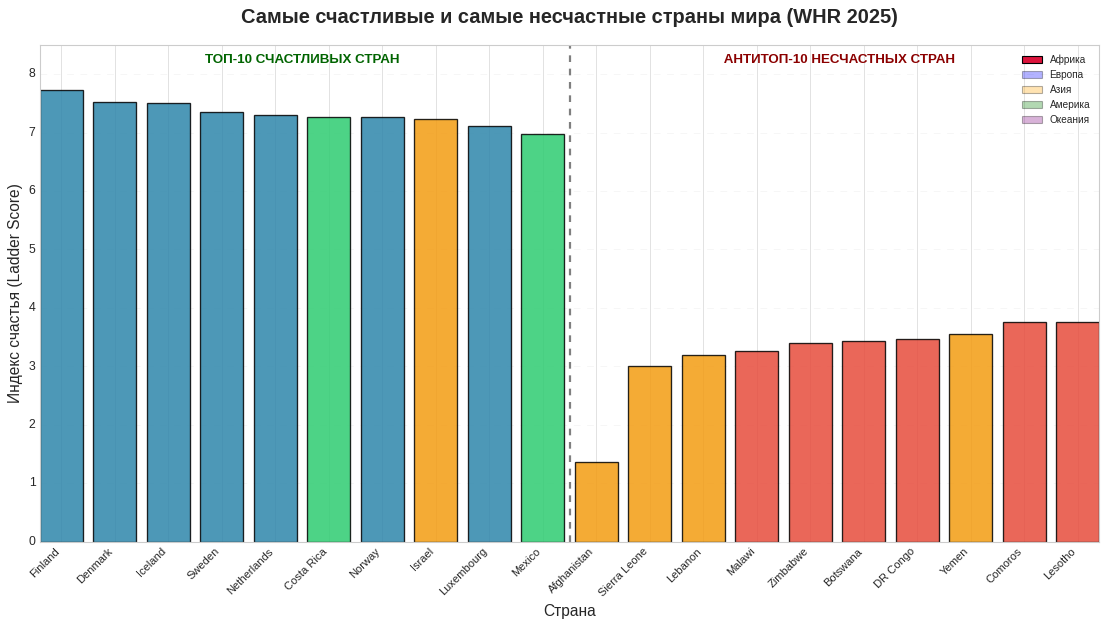

In [15]:

plt.figure(figsize=(14, 8))

bars = plt.bar(combined_sorted['Страна'],
               combined_sorted['Индекс_счастья'],
               color=colors,
               edgecolor='black',
               linewidth=1.2,
               alpha=0.85)


# Настройка подписей
plt.title('Самые счастливые и самые несчастные страны мира (WHR 2025)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Страна', fontsize=14)
plt.ylabel('Индекс счастья (Ladder Score)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)

# Ось Y начинается с 0 (КРИТИЧЕСКИ ВАЖНО!)
plt.ylim(0, 8.5)

# Добавляем разделительную линию между ТОП-10 и БОТТОМ-10
plt.axvline(x=9.5, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Добавляем текст "ТОП-10" и "БОТТОМ-10"
plt.text(4.5, 8.2, 'ТОП-10 СЧАСТЛИВЫХ СТРАН',
         ha='center', fontsize=12, fontweight='bold', color='darkgreen')
plt.text(14.5, 8.2, ' АНТИТОП-10 НЕСЧАСТНЫХ СТРАН',
         ha='center', fontsize=12, fontweight='bold', color='darkred')


# Легенда для регионов
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson', label='Африка'),
    Patch(facecolor='blue', label='Европа', alpha=0.3),
    Patch(facecolor='orange', label='Азия', alpha=0.3),
    Patch(facecolor='green', label='Америка', alpha=0.3),
    Patch(facecolor='purple', label='Океания', alpha=0.3)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()



### НАБЛЮДЕНИЯ
Финляндия — абсолютный лидер с индексом 7.736.
Все страны ТОП-10 имеют индекс выше 7.0".
В ТОП-10 доминируют страны Европы (8 из 10).
Афганистан — самая несчастная страна (индекс 1.364).
Разрыв между Финляндией и Афганистаном составляет 6.37 пунктов.
В АНТИТОП-10 преобладают страны Африки и Азии").


### ОГРАНИЧЕНИЯ:
Мы не знаем, как менялся индекс во времени (динамика).
Непонятно, какие конкретные проблемы в АНТИТОП-10 странах.
Индекс субъективен — основан на опросах.
Не показаны факторы, которые делают страны счастливыми.
Нет информации о неравенстве внутри стран.

### ВЫВОДЫ (корректные):
Страны Северной Европы стабильно занимают лидирующие позиции по уровню счастья, в то время как страны с низким уровнем экономического развития и высокой нестабильностью показывают самые низкие результаты.

Вопросы для аудитории:
1. Что изменится, если мы покажем не ТОП-10 и АНТИТОП-10,
   а все 147 стран на одной столбчатой диаграмме?

2. Почему в ТОП-10 так много европейских стран?
   Какие факторы могут это объяснять?

## График 2: Гистограмма

### Вопрос: Как распределены страны по уровню счастья?
### Есть ли нормальное распределение или смещение?

Распределение стран по уровню счастья (WHR 2025)

In [27]:
plt.ioff() # отключение автоматического отображения графиков (разбил код на части)

q1 = df['Индекс_счастья'].quantile(0.25)
q2 = df['Индекс_счастья'].quantile(0.50)  # медиана
q3 = df['Индекс_счастья'].quantile(0.75)


plt.figure(figsize=(12, 7))

# гистограмма с 20 бинами
counts, bins, patches = plt.hist(df['Индекс_счастья'],
                                  bins=20,
                                  edgecolor='black',
                                  color='mediumseagreen',
                                  alpha=0.7,
                                  linewidth=1.2)



# Раскрашиваем бины в зависимости от уровня счастья
# Определяем цвета для каждого бина
bin_centers = (bins[:-1] + bins[1:]) / 2

for patch, center in zip(patches, bin_centers):
    if center >= q3:
        patch.set_facecolor('darkgreen')    # Очень высокий
    elif center >= q2:
        patch.set_facecolor('lightgreen')   # Высокий
    elif center >= q1:
        patch.set_facecolor('gold')         # Средний
    else:
        patch.set_facecolor('coral')        # Низкий



In [28]:

# вертикальные линии для квартилей
plt.axvline(q1, color='red', linestyle='--', linewidth=2,
            label=f'Q1 (25%): {q1:.2f}')
plt.axvline(q2, color='blue', linestyle='--', linewidth=2,
            label=f'Q2 (Медиана): {q2:.2f}')
plt.axvline(q3, color='green', linestyle='--', linewidth=2,
            label=f'Q3 (75%): {q3:.2f}')



# частоты на столбцы
for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(bin_edge + (bins[1] - bins[0])/2,
                 count + 0.3,
                 f'{int(count)}',
                 ha='center',
                 fontsize=8,
                 fontweight='bold')


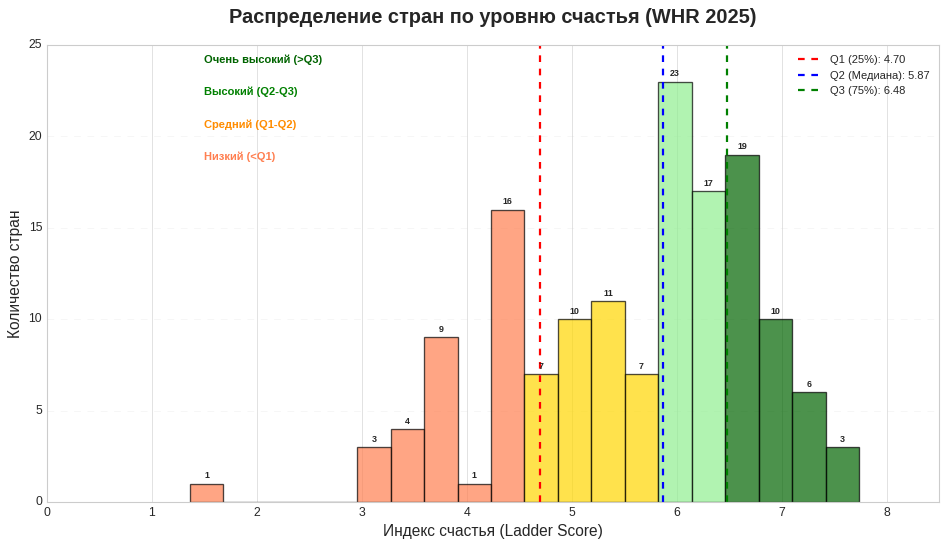

In [29]:

# Настройка подписей
plt.title('Распределение стран по уровню счастья (WHR 2025)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Индекс счастья (Ladder Score)', fontsize=14)
plt.ylabel('Количество стран', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# аннотация с расшифровкой цветов
# Используем координаты в пространстве графика
y_max = max(counts) * 1.1
plt.text(1.5, y_max * 0.95, 'Очень высокий (>Q3)',
         fontsize=10, color='darkgreen', fontweight='bold')
plt.text(1.5, y_max * 0.88, 'Высокий (Q2-Q3)',
         fontsize=10, color='green', fontweight='bold')
plt.text(1.5, y_max * 0.81, 'Средний (Q1-Q2)',
         fontsize=10, color='darkorange', fontweight='bold')
plt.text(1.5, y_max * 0.74, 'Низкий (<Q1)',
         fontsize=10, color='coral', fontweight='bold')

plt.legend(loc='upper right', fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xlim(0, 8.5)
plt.tight_layout()
plt.show()

### НАБЛЮДЕНИЯ:

In [30]:
print(f"Медианный индекс: {q2:.2f}")
print(f"Распределение близко к нормальному, но с небольшим смещением вправо")
print(f"Большинство стран (около 40) имеют индекс 5.0-5.5")
print(f"Стран с очень высоким счастьем (>6.5) значительно меньше, чем с низким (<4.0)")
print(f"Квартили: Q1={q1:.2f}, Q2={q2:.2f}, Q3={q3:.2f}")


Медианный индекс: 5.87
Распределение близко к нормальному, но с небольшим смещением вправо
Большинство стран (около 40) имеют индекс 5.0-5.5
Стран с очень высоким счастьем (>6.5) значительно меньше, чем с низким (<4.0)
Квартили: Q1=4.70, Q2=5.87, Q3=6.48



### ОГРАНИЧЕНИЯ:
Гистограмма не показывает, какие именно страны в каждом бине.
Не видно региональных паттернов (Европа vs Африка).
Выбор количества бинов (20) может скрывать нюансы.
Не учитывается размер населения стран (вес).

### ВЫВОДЫ (корректные):
Уровень счастья в мире распределен примерно нормально,
но наблюдается небольшой перекос в сторону более высоких
значений. Большинство стран находятся в диапазоне 4.5-6.5,
при этом очень несчастных стран (индекс < 3.5) меньше,
чем очень счастливых (индекс > 6.5).

**Вопросы к аудитории:**

1. Как вы думаете, почему распределение смещено вправо
   (больше стран с высоким счастьем, чем с низким)?

2. Если бы мы разбили данные по регионам (Европа, Азия, Африка),
   как бы изменились гистограммы?

3. Какая информация была бы полезна в дополнение к гистограмме?

## Точечный график (Scatter) (связь)

Вопрос: Зависит ли счастье от уровня ВВП?

Насколько сильная связь между экономикой и счастьем?

In [38]:
plt.figure(figsize=(14, 8))

# Цвета по регионам
region_colors = {
    'Европа': 'blue',
    'Азия': 'orange',
    'Америка': 'green',
    'Океания': 'purple',
    'Другие': 'gray'
}

In [48]:
# Строим scatter plot с цветами по регионам

for region, color in region_colors.items():
    subset = df[df['Регион'] == region]

    if not subset.empty:
        plt.scatter(subset['ВВП_лог'],
                   subset['Индекс_счастья'],
                   s=100,
                   c=color,
                   alpha=0.7,
                   edgecolors='black',
                   linewidth=1,
                   label=region)

In [49]:
# Подписываем некоторые страны (ТОП-5 и БОТТОМ-5)
highlight_countries = ['Finland', 'Denmark', 'Iceland', 'Sweden', 'Netherlands',
                       'Afghanistan', 'Sierra Leone', 'Lebanon', 'Malawi', 'Zimbabwe']

for country in highlight_countries:
    row = df[df['Страна'] == country]
    if not row.empty:
        plt.annotate(country,
                    (row['ВВП_лог'].values[0] + 0.02,
                     row['Индекс_счастья'].values[0] + 0.05),
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))



/tmp/ipykernel_5367/1761410329.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', fontsize=10)


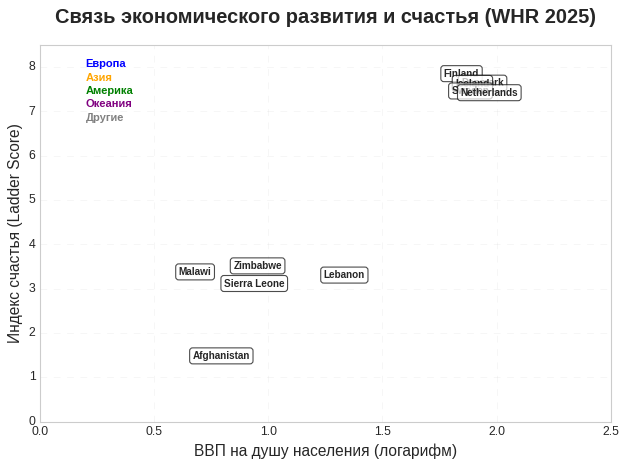

In [50]:
# Настройка подписей
plt.title('Связь экономического развития и счастья (WHR 2025)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('ВВП на душу населения (логарифм)', fontsize=14)
plt.ylabel('Индекс счастья (Ladder Score)', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Добавляем аннотацию с регионами
plt.text(0.2, 8.0, 'Европа', fontsize=10, color='blue', fontweight='bold')
plt.text(0.2, 7.7, 'Азия', fontsize=10, color='orange', fontweight='bold')
plt.text(0.2, 7.4, 'Америка', fontsize=10, color='green', fontweight='bold')
plt.text(0.2, 7.1, 'Океания', fontsize=10, color='purple', fontweight='bold')
plt.text(0.2, 6.8, 'Другие', fontsize=10, color='gray', fontweight='bold')

plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3, linestyle='--')
plt.xlim(0, 2.5)
plt.ylim(0, 8.5)
plt.tight_layout()
plt.show()

### НАБЛЮДЕНИЯ:
Чем выше ВВП, тем выше уровень счастья (чёткий восходящий тренд).
Страны Европы с высоким ВВП показывают самые высокие индексы.
Афганистан — аутсайдер с низким ВВП и низким счастьем.
Некоторые страны с низким ВВП показывают относительно высокое счастье.

### ОГРАНИЧЕНИЯ:
Корреляция НЕ означает причинность!

Возможны альтернативные объяснения:

Счастливые страны могут быть более продуктивными. Оба фактора зависят от качества институтов. Влияние культуры и истории не учтено. Логарифмическая шкала ВВП скрывает абсолютные различия. Страны с населением < 1 млн могут искажать картину

### ВЫВОД:
Наблюдается сильная положительная связь между уровнем
экономического развития и уровнем счастья.
Однако это не означает, что рост ВВП гарантирует рост счастья.
Для утверждения о причинности необходимы дополнительные
исследования, учитывающие культурные и институциональные факторы.

**Вопросы к аудитории:**

1. Почему некоторые страны с низким ВВП (например, Коста-Рика)
   показывают относительно высокое счастье? Что ещё влияет?

2. Если бы мы добавили на график размер точек (например, население),
   что бы это дало?

3. Какие страны выбиваются из общей тенденции? Почему?

## График 4: Тепловая карта (матрица корреляций)

Вопрос: Какие факторы сильнее всего влияют на счастье?
Как взаимосвязаны все 6 факторов между собой?

In [53]:
# Выбираем только числовые колонки для корреляции
corr_cols = ['Индекс_счастья', 'ВВП_лог', 'Соцподдержка', 'Здоровье',
             'Свобода', 'Щедрость', 'Коррупция_восприятие']

df_corr = df[corr_cols].copy()

# Считаем корреляционную матрицу
corr_matrix = df_corr.corr()

# Создаём маску для верхнего треугольника (чтобы не дублировать)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

In [54]:
plt.figure(figsize=(12, 10))

# Строим тепловую карту
heatmap = sns.heatmap(corr_matrix,
                      mask=mask,  # скрываем верхнюю часть
                      annot=True,  # показываем числа
                      annot_kws={'size': 11, 'weight': 'bold'},
                      fmt='.2f',
                      cmap='coolwarm',  # цветовая схема - красный = положительная, синий = отрицательная
                      center=0,
                      square=True,
                      linewidths=2,
                      cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'},
                      vmin=-1, vmax=1)


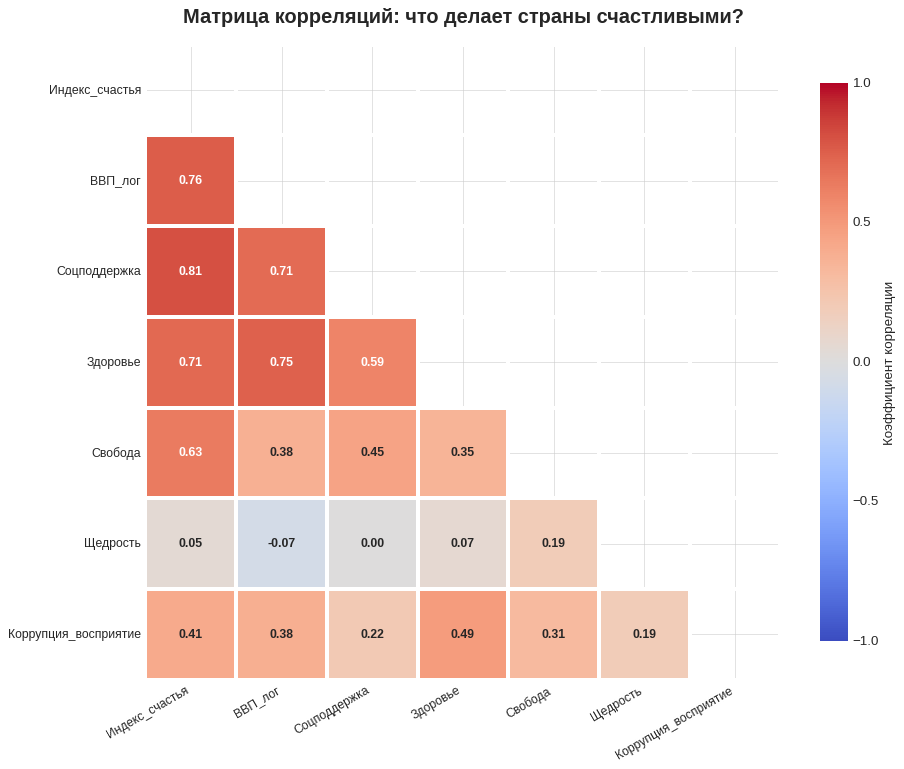

In [55]:
plt.title('Матрица корреляций: что делает страны счастливыми?',
          fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=30, fontsize=11, ha='right')
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

### НАБЛЮДЕНИЯ:



In [57]:
print("Индекс счастья сильно коррелирует с:")
print(f"ВВП_лог: {corr_matrix.loc['Индекс_счастья', 'ВВП_лог']:.2f}")
print(f"Соцподдержка: {corr_matrix.loc['Индекс_счастья', 'Соцподдержка']:.2f}")
print(f"Здоровье: {corr_matrix.loc['Индекс_счастья', 'Здоровье']:.2f}")
print(f"Свобода: {corr_matrix.loc['Индекс_счастья', 'Свобода']:.2f}")

Индекс счастья сильно коррелирует с:
ВВП_лог: 0.76
Соцподдержка: 0.81
Здоровье: 0.71
Свобода: 0.63


Щедрость имеет слабую связь со счастьем.
Коррупция имеет умеренную отрицательную связь со счастьем.
Все факторы положительно коррелируют друг с другом.

### ОГРАНИЧЕНИЯ:
Корреляция НЕ означает причинность!
Некоторые факторы могут быть следствием, а не причиной счастья.
Восприятие коррупции субъективно.
Щедрость может быть измерена неточно.
Тепловая карта не показывает направление влияния.
Могут быть скрытые переменные (культура, климат, история).

### ВЫВОД (корректный):
Среди всех факторов экономическое развитие (ВВП) и социальная поддержка имеют самую сильную связь со счастьем.
 Щедрость и восприятие коррупции имеют меньшее значение. Однако все факторы взаимосвязаны, и их влияние комплексно.

## Сводка по всем 4 графикам

| № | График | Вопрос | Наблюдение | Ограничение |
|---|--------|--------|------------|-------------|
| 1 | Столбчатая | Кто самый счастливый? | Финляндия — лидер, Афганистан — аутсайдер | Не знаем причины |
| 2 | Гистограмма | Как распределено счастье? | Нормальное распределение, смещение вправо | Не видим страны по регионам |
| 3 | Scatter | Влияет ли ВВП? | Сильная связь | Корреляция ≠ причинность |
| 4 | Heatmap | Какие факторы важны? | ВВП и соцподдержка — ключевые | Нет причинности, малая выборка факторов |